# GA Feature Selection Research Project — Optimized
## Setup and Installation

**Evaluating the Generalization Ability of Genetic Algorithm-Based Feature Selection in Tabular Machine Learning Models**

Research Question: Does Genetic Algorithm-based feature selection improve or reduce cross-dataset generalization performance when compared to traditional feature selection techniques?

**Optimizations in this version**:
- GPU acceleration for XGBoost, LightGBM, CatBoost (when available)
- GA fitness caching (~20–40% hit rate typical)
- GA fitness subsampling (large speedup with minimal quality loss)
- GA early stopping on stagnation
- Parallel population fitness evaluation
- VarianceThreshold preprocessing to drop zero-variance columns after one-hot
- Extended classifier suite (ExtraTrees, CatBoost, KNN, DecisionTree, HistGradientBoosting)
- Reuse of pre-fit GA selections across experiments
- Per-generation CSV logging for paper analysis


In [1]:
from IPython.display import display, Javascript

display(Javascript('''
function ClickConnect(){
    console.log("Keep-alive ping: " + new Date().toLocaleTimeString());

    let btn = document.querySelector("colab-toolbar-button#connect");
    if (!btn) btn = document.querySelector("colab-connect-button");
    if (btn && btn.shadowRoot) {
        let inner = btn.shadowRoot.querySelector("#connect");
        if (inner) inner.click();
    } else if (btn) {
        btn.click();
    }
}

setInterval(ClickConnect, 60 * 1000);
console.log("Colab keep-alive started.");
'''))

print('Keep-alive script installed. It will ping every 60 seconds.')
print('Note: this only prevents IDLE disconnects. The 12-hour max session limit still applies.')

<IPython.core.display.Javascript object>

Keep-alive script installed. It will ping every 60 seconds.
Note: this only prevents IDLE disconnects. The 12-hour max session limit still applies.


In [2]:
import os
import subprocess
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

PROJECT_DIR    = Path('/content/drive/MyDrive/IDAI-720')
DATA_DIR       = PROJECT_DIR / 'datasets'
NSL_DIR        = DATA_DIR    / 'nsl_kdd'
UNSW_DIR       = DATA_DIR    / 'unsw_nb15'
CICIDS_DIR     = DATA_DIR    / 'cicids2017'
RESULTS_DIR    = PROJECT_DIR / 'ga_results'
FIGURES_DIR    = PROJECT_DIR / 'ga_figures'
CHECKPOINT_DIR = PROJECT_DIR / 'ga_checkpoints'

for d in [PROJECT_DIR, DATA_DIR, NSL_DIR, UNSW_DIR, CICIDS_DIR,
          RESULTS_DIR, FIGURES_DIR, CHECKPOINT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'Project root: {PROJECT_DIR}')
print(f'Datasets:     {DATA_DIR}')
print(f'Results:      {RESULTS_DIR}')
print(f'Figures:      {FIGURES_DIR}')
print(f'Checkpoints:  {CHECKPOINT_DIR}')



MIN_VALID_SIZE = 100_000  #


def safe_download(primary_url, dest, fallback_urls=None, min_size=MIN_VALID_SIZE):
    """Download to dest, retrying with fallbacks if file is missing, empty, or too small."""
    urls = [primary_url] + list(fallback_urls or [])

    if dest.exists() and dest.stat().st_size >= min_size:
        print(f'  OK (cached): {dest.name} ({dest.stat().st_size // 1024} KB)')
        return True

    if dest.exists() and dest.stat().st_size < min_size:
        dest.unlink()

    for attempt_url in urls:
        print(f'  Downloading {dest.name} from {attempt_url}')
        subprocess.run(
            ['wget', '-q', '--tries=3', '--timeout=30', '-O', str(dest), attempt_url],
            capture_output=True, text=True
        )
        if dest.exists() and dest.stat().st_size >= min_size:
            print(f'  OK: {dest.name} ({dest.stat().st_size // 1024} KB)')
            return True
        size = dest.stat().st_size if dest.exists() else 0
        print(f'  FAILED ({size} bytes) from {attempt_url}')
        if dest.exists():
            dest.unlink()
    return False


# NSL-KDD
NSL_TRAIN_URLS = [
    'https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt',
    'https://raw.githubusercontent.com/HoaNP/NSL-KDD-DataSet/master/KDDTrain%2B.txt',
]
NSL_TEST_URLS = [
    'https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest+.txt',
    'https://raw.githubusercontent.com/HoaNP/NSL-KDD-DataSet/master/KDDTest%2B.txt',
]

print('\n=== NSL-KDD ===')
ok1 = safe_download(NSL_TRAIN_URLS[0], NSL_DIR / 'KDDTrain+.txt',
                    fallback_urls=NSL_TRAIN_URLS[1:])
ok2 = safe_download(NSL_TEST_URLS[0],  NSL_DIR / 'KDDTest+.txt',
                    fallback_urls=NSL_TEST_URLS[1:])
assert ok1 and ok2, 'NSL-KDD download failed from all mirrors.'

# UNSW-NB15
UNSW_TRAIN_URLS = [
    'https://raw.githubusercontent.com/Nir-J/ML-Projects/master/UNSW-Network_Packet_Classification/UNSW_NB15_training-set.csv',
]
UNSW_TEST_URLS = [
    'https://raw.githubusercontent.com/Nir-J/ML-Projects/master/UNSW-Network_Packet_Classification/UNSW_NB15_testing-set.csv',
]

print('\n=== UNSW-NB15 ===')
ok3 = safe_download(UNSW_TRAIN_URLS[0], UNSW_DIR / 'UNSW_NB15_training-set.csv',
                    fallback_urls=UNSW_TRAIN_URLS[1:])
ok4 = safe_download(UNSW_TEST_URLS[0],  UNSW_DIR / 'UNSW_NB15_testing-set.csv',
                    fallback_urls=UNSW_TEST_URLS[1:])
assert ok3 and ok4, (
    'UNSW-NB15 download failed. Manual fallback: download from '
    'https://research.unsw.edu.au/projects/unsw-nb15-dataset and upload to '
    f'{UNSW_DIR}/'
)

print('\nAll datasets ready.')
print('NSL-KDD train:', (NSL_DIR / 'KDDTrain+.txt').stat().st_size // 1024, 'KB')
print('NSL-KDD test: ', (NSL_DIR / 'KDDTest+.txt').stat().st_size // 1024, 'KB')
print('UNSW train:   ', (UNSW_DIR / 'UNSW_NB15_training-set.csv').stat().st_size // 1024, 'KB')
print('UNSW test:    ', (UNSW_DIR / 'UNSW_NB15_testing-set.csv').stat().st_size // 1024, 'KB')

Mounted at /content/drive
Project root: /content/drive/MyDrive/IDAI-720
Datasets:     /content/drive/MyDrive/IDAI-720/datasets
Results:      /content/drive/MyDrive/IDAI-720/ga_results
Figures:      /content/drive/MyDrive/IDAI-720/ga_figures
Checkpoints:  /content/drive/MyDrive/IDAI-720/ga_checkpoints

=== NSL-KDD ===
  OK (cached): KDDTrain+.txt (18661 KB)
  OK (cached): KDDTest+.txt (3360 KB)

=== UNSW-NB15 ===
  OK (cached): UNSW_NB15_training-set.csv (31536 KB)
  OK (cached): UNSW_NB15_testing-set.csv (15020 KB)

All datasets ready.
NSL-KDD train: 18661 KB
NSL-KDD test:  3360 KB
UNSW train:    31536 KB
UNSW test:     15020 KB


In [3]:
!pip install xgboost lightgbm catboost imbalanced-learn statsmodels tqdm --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import joblib
import warnings
import time
import subprocess
from datetime import datetime
from pathlib import Path
from itertools import combinations
from collections import namedtuple

from joblib import Parallel, delayed
from tqdm.auto import tqdm

from sklearn.model_selection import (StratifiedKFold, StratifiedShuffleSplit,
                                     train_test_split, cross_val_score, cross_val_predict)
from sklearn.preprocessing import (StandardScaler, MinMaxScaler,
                                   OneHotEncoder, LabelEncoder)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import (SelectKBest, mutual_info_classif,
                                       chi2, SelectFromModel, RFE, VarianceThreshold)
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               GradientBoostingClassifier, HistGradientBoostingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report)
from sklearn.utils.class_weight import compute_class_weight

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE

from scipy import stats
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['figure.dpi']  = 100
np.random.seed(42)


try:
    from google.colab import drive
    drive.mount('/content/drive')
    RESULTS_DIR    = Path('/content/drive/MyDrive/IDAI-720/ga_results')    # ✅ fixed
    FIGURES_DIR    = Path('/content/drive/MyDrive/IDAI-720/ga_figures')    # ✅ fixed
    CHECKPOINT_DIR = Path('/content/drive/MyDrive/IDAI-720/ga_checkpoints')# ✅ fixed
except Exception as e:
    print(f'Drive mount failed: {e}. Using local directories instead.')
    RESULTS_DIR    = Path('/content/ga_results')
    FIGURES_DIR    = Path('/content/ga_figures')
    CHECKPOINT_DIR = Path('/content/ga_checkpoints')

for d in [RESULTS_DIR, FIGURES_DIR, CHECKPOINT_DIR]:
    d.mkdir(parents=True, exist_ok=True)


USE_GPU = True

GPU_AVAILABLE = False
if USE_GPU:
    try:
        r = subprocess.run(['nvidia-smi'], capture_output=True, text=True, timeout=5)
        GPU_AVAILABLE = (r.returncode == 0)
    except Exception:
        GPU_AVAILABLE = False

XGB_GPU_KWARGS      = {'tree_method': 'hist', 'device': 'cuda'} if GPU_AVAILABLE else {}
LGBM_GPU_KWARGS     = {'device': 'gpu'} if GPU_AVAILABLE else {}
CATBOOST_GPU_KWARGS = {'task_type': 'GPU'} if GPU_AVAILABLE else {}

print('All imports successful.')
print('NumPy:', np.__version__)
print('Pandas:', pd.__version__)
print('Sklearn:', __import__('sklearn').__version__)
print(f'USE_GPU flag:  {USE_GPU}')
print(f'GPU detected:  {GPU_AVAILABLE}')
if GPU_AVAILABLE:
    print('XGBoost + LightGBM + CatBoost will use GPU. Sklearn models remain on CPU.')
else:
    print('Running CPU-only.')
print('Results dir:   ', RESULTS_DIR)
print('Figures dir:   ', FIGURES_DIR)
print('Checkpoint dir:', CHECKPOINT_DIR)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All imports successful.
NumPy: 2.0.2
Pandas: 2.2.2
Sklearn: 1.6.1
USE_GPU flag:  True
GPU detected:  True
XGBoost + LightGBM + CatBoost will use GPU. Sklearn models remain on CPU.
Results dir:    /content/drive/MyDrive/IDAI-720/ga_results
Figures dir:    /content/drive/MyDrive/IDAI-720/ga_figures
Checkpoint dir: /content/drive/MyDrive/IDAI-720/ga_checkpoints


In [4]:
# DATA LOADER

NSL_KDD_COLUMNS = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate','class','difficulty'
]

NSL_KDD_NUMERIC = [
    'duration','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot',
    'num_failed_logins','logged_in','num_compromised','root_shell','su_attempted',
    'num_root','num_file_creations','num_shells','num_access_files',
    'num_outbound_cmds','is_host_login','is_guest_login','count','srv_count',
    'serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate',
    'same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count',
    'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate'
]

NSL_KDD_CATEGORICAL = ['protocol_type', 'service', 'flag']

DatasetBundle = namedtuple('DatasetBundle', [
    'X_train', 'X_test', 'y_train', 'y_test',
    'feature_names', 'numeric_cols', 'categorical_cols', 'dataset_name'
])


def load_nsl_kdd(train_path, test_path, binary=True):
    """Load the NSL-KDD dataset and return a DatasetBundle."""
    print(f'Loading NSL-KDD from {train_path} and {test_path} ...')
    df_train = pd.read_csv(train_path, header=None, names=NSL_KDD_COLUMNS)
    df_test  = pd.read_csv(test_path,  header=None, names=NSL_KDD_COLUMNS)

    # Drop difficulty column
    df_train = df_train.drop(columns=['difficulty'])
    df_test  = df_test.drop(columns=['difficulty'])

    # Remove duplicates
    before_tr = len(df_train)
    before_te = len(df_test)
    df_train = df_train.drop_duplicates().reset_index(drop=True)
    df_test  = df_test.drop_duplicates().reset_index(drop=True)
    print(f'  Duplicates dropped — train: {before_tr - len(df_train)}, test: {before_te - len(df_test)}')

    # Binary label: normal=0, else=1
    if binary:
        df_train['label'] = (df_train['class'] != 'normal').astype(int)
        df_test['label']  = (df_test['class']  != 'normal').astype(int)
    else:
        df_train['label'] = df_train['class']
        df_test['label']  = df_test['class']
    df_train = df_train.drop(columns=['class'])
    df_test  = df_test.drop(columns=['class'])

    feature_cols = [c for c in df_train.columns if c != 'label']
    X_train = df_train[feature_cols].copy()
    y_train = df_train['label'].values
    X_test  = df_test[feature_cols].copy()
    y_test  = df_test['label'].values

    return DatasetBundle(
        X_train=X_train, X_test=X_test,
        y_train=y_train, y_test=y_test,
        feature_names=feature_cols,
        numeric_cols=NSL_KDD_NUMERIC,
        categorical_cols=NSL_KDD_CATEGORICAL,
        dataset_name='nsl_kdd'
    )


def load_unsw_nb15(train_path, test_path):
    """Load the UNSW-NB15 dataset and return a DatasetBundle."""
    print(f'Loading UNSW-NB15 from {train_path} and {test_path} ...')
    df_train = pd.read_csv(train_path)
    df_test  = pd.read_csv(test_path)

    # Drop id column if present
    for col in ['id', 'Id', 'ID']:
        if col in df_train.columns:
            df_train = df_train.drop(columns=[col])
        if col in df_test.columns:
            df_test = df_test.drop(columns=[col])

    # Drop attack_cat to avoid target leakage (label already binary)
    for col in ['attack_cat']:
        if col in df_train.columns:
            df_train = df_train.drop(columns=[col])
        if col in df_test.columns:
            df_test = df_test.drop(columns=[col])

    # Remove duplicates
    before_tr = len(df_train)
    before_te = len(df_test)
    df_train = df_train.drop_duplicates().reset_index(drop=True)
    df_test  = df_test.drop_duplicates().reset_index(drop=True)
    print(f'  Duplicates dropped — train: {before_tr - len(df_train)}, test: {before_te - len(df_test)}')

    target_col = 'label'
    feature_cols = [c for c in df_train.columns if c != target_col]

    # Identify numeric vs categorical automatically
    numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_train[c])]
    categorical_cols = [c for c in feature_cols if c not in numeric_cols]

    print(f'  Numeric columns ({len(numeric_cols)}):    {numeric_cols[:6]}...')
    print(f'  Categorical columns ({len(categorical_cols)}): {categorical_cols}')

    X_train = df_train[feature_cols].copy()
    y_train = df_train[target_col].values.astype(int)
    X_test  = df_test[feature_cols].copy()
    y_test  = df_test[target_col].values.astype(int)

    return DatasetBundle(
        X_train=X_train, X_test=X_test,
        y_train=y_train, y_test=y_test,
        feature_names=feature_cols,
        numeric_cols=numeric_cols,
        categorical_cols=categorical_cols,
        dataset_name='unsw_nb15'
    )


def summarize_bundle(bundle):
    """Print a summary of the DatasetBundle."""
    print(f'\n===== {bundle.dataset_name.upper()} SUMMARY =====')
    print(f'Train shape: {bundle.X_train.shape}   Test shape: {bundle.X_test.shape}')
    y_tr = bundle.y_train
    y_te = bundle.y_test
    tr_vals, tr_cnt = np.unique(y_tr, return_counts=True)
    te_vals, te_cnt = np.unique(y_te, return_counts=True)
    print(f'Train class counts: {dict(zip(tr_vals.tolist(), tr_cnt.tolist()))}')
    print(f'Test  class counts: {dict(zip(te_vals.tolist(), te_cnt.tolist()))}')
    if len(tr_cnt) >= 2:
        bal = tr_cnt.min() / tr_cnt.max()
        print(f'Train class balance ratio: {bal:.3f}')
    print(f'Numeric cols:    {len(bundle.numeric_cols)}')
    print(f'Categorical cols:{len(bundle.categorical_cols)}')
    print(f'Total features:  {len(bundle.feature_names)}')


print('data_loader module ready.')


data_loader module ready.


In [5]:
# PREPROCESSING

def build_preprocessor(numeric_cols, categorical_cols):
    """Construct a ColumnTransformer for numeric + categorical columns."""
    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler())
    ])
    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    pre = ColumnTransformer(transformers=[
        ('num', numeric_pipeline,     numeric_cols),
        ('cat', categorical_pipeline, categorical_cols)
    ], remainder='drop')
    return pre


def _clean_feature_names(raw_names):
    cleaned = []
    for n in raw_names:
        s = str(n)
        if s.startswith('num__'):
            s = s[len('num__'):]
        elif s.startswith('cat__'):
            s = s[len('cat__'):]
        cleaned.append(s)
    return cleaned


def preprocess_dataset(bundle, use_smote=False, drop_zero_variance=True):
    """Fit preprocessor on train, transform train and test, optionally apply SMOTE + variance threshold."""
    print(f'Preprocessing {bundle.dataset_name} (use_smote={use_smote}) ...')
    print(f'  Before — X_train: {bundle.X_train.shape}  X_test: {bundle.X_test.shape}')
    pre = build_preprocessor(bundle.numeric_cols, bundle.categorical_cols)
    X_train_proc = pre.fit_transform(bundle.X_train)
    X_test_proc  = pre.transform(bundle.X_test)

    try:
        raw_names = pre.get_feature_names_out()
    except Exception:
        raw_names = [f'f{i}' for i in range(X_train_proc.shape[1])]
    feature_names_out = _clean_feature_names(raw_names)

    # Drop zero-variance columns (common after one-hot encoding rare categories)
    if drop_zero_variance:
        vt = VarianceThreshold(threshold=0.0)
        X_train_proc = vt.fit_transform(X_train_proc)
        X_test_proc  = vt.transform(X_test_proc)
        kept = vt.get_support()
        dropped = int((~kept).sum())
        feature_names_out = [n for n, k in zip(feature_names_out, kept) if k]
        print(f'  VarianceThreshold dropped {dropped} zero-variance columns.')

    y_train = bundle.y_train.copy()
    y_test  = bundle.y_test.copy()

    if use_smote:
        smote = SMOTE(random_state=42)
        X_train_proc, y_train = smote.fit_resample(X_train_proc, y_train)
        print(f'  After SMOTE — X_train: {X_train_proc.shape}')

    print(f'  After  — X_train: {X_train_proc.shape}  X_test: {X_test_proc.shape}')
    print(f'  Feature names (first 5): {feature_names_out[:5]}')
    print(f'  Feature names (last 5):  {feature_names_out[-5:]}')

    ckpt_path = CHECKPOINT_DIR / f'{bundle.dataset_name}_preprocessor.pkl'
    joblib.dump({'preprocessor': pre, 'feature_names': feature_names_out}, ckpt_path)
    print(f'  Preprocessor saved to {ckpt_path}')

    return X_train_proc, X_test_proc, y_train, y_test, feature_names_out


print('preprocessing module ready.')


preprocessing module ready.


In [6]:
#  MODELS

def get_models():
    """Return the full dictionary of classifiers for all experiments."""
    return {
        'LogisticRegression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1),
        'LinearSVM':          LinearSVC(class_weight='balanced', random_state=42, max_iter=2000, dual='auto'),
        'DecisionTree':       DecisionTreeClassifier(class_weight='balanced', random_state=42, max_depth=15),
        'RandomForest':       RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
        'ExtraTrees':         ExtraTreesClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
        'GradientBoosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
        'HistGradientBoosting': HistGradientBoostingClassifier(max_iter=100, random_state=42, class_weight='balanced'),
        'XGBoost':            XGBClassifier(n_estimators=100, scale_pos_weight=1, random_state=42,
                                            eval_metric='logloss', verbosity=0, **XGB_GPU_KWARGS),
        'LightGBM':           LGBMClassifier(n_estimators=100, class_weight='balanced', random_state=42,
                                             verbose=-1, **LGBM_GPU_KWARGS),
        'CatBoost':           CatBoostClassifier(iterations=100, random_state=42, verbose=0,
                                                  auto_class_weights='Balanced', **CATBOOST_GPU_KWARGS),
        'KNN':                KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
        'MLP':                MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300, random_state=42)
    }


def fast_models():
    """Smaller model dictionary for quick inner-loop experiments."""
    return {
        'LogisticRegression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1),
        'RandomForest':       RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
    }


print('models module ready — {} full models, {} fast models.'.format(len(get_models()), len(fast_models())))


models module ready — 12 full models, 2 fast models.


In [7]:
# FEATURE SELECTION BASELINES

class BaseSelector:
    """Common interface for all feature selectors."""
    def __init__(self):
        self.selected_indices_       = None
        self.selected_feature_names_ = None
        self.n_selected_             = None
        self.reduction_ratio_        = None
        self._feature_names_in       = None

    def fit(self, X, y, feature_names=None):
        raise NotImplementedError

    def transform(self, X):
        if self.selected_indices_ is None:
            raise RuntimeError('Selector has not been fitted yet.')
        return X[:, self.selected_indices_]

    def fit_transform(self, X, y, feature_names=None):
        self.fit(X, y, feature_names=feature_names)
        return self.transform(X)

    def _finalize(self, indices, n_total, feature_names):
        indices = np.asarray(indices, dtype=int)
        self.selected_indices_ = indices
        self.n_selected_       = int(len(indices))
        self.reduction_ratio_  = 1.0 - (self.n_selected_ / max(n_total, 1))
        if feature_names is not None:
            self.selected_feature_names_ = [feature_names[i] for i in indices]
        else:
            self.selected_feature_names_ = [f'f{i}' for i in indices]


class NoSelector(BaseSelector):
    name = 'NoSelection'
    def fit(self, X, y, feature_names=None):
        n = X.shape[1]
        self._finalize(np.arange(n), n, feature_names)
        return self


class MutualInfoSelector(BaseSelector):
    name = 'MutualInfo'
    def __init__(self, k=20):
        super().__init__()
        self.k = k
    def fit(self, X, y, feature_names=None):
        n = X.shape[1]
        k_eff = min(self.k, n)
        sk = SelectKBest(score_func=mutual_info_classif, k=k_eff)
        sk.fit(X, y)
        idx = np.where(sk.get_support())[0]
        self._finalize(idx, n, feature_names)
        self._sk = sk
        return self


class ChiSquareSelector(BaseSelector):
    name = 'ChiSquare'
    def __init__(self, k=20):
        super().__init__()
        self.k = k
    def fit(self, X, y, feature_names=None):
        n = X.shape[1]
        k_eff = min(self.k, n)
        mm = MinMaxScaler()
        X_nn = mm.fit_transform(X)
        sk = SelectKBest(score_func=chi2, k=k_eff)
        sk.fit(X_nn, y)
        idx = np.where(sk.get_support())[0]
        self._finalize(idx, n, feature_names)
        return self


class L1Selector(BaseSelector):
    name = 'L1Logistic'
    def __init__(self, C=0.1):
        super().__init__()
        self.C = C
    def fit(self, X, y, feature_names=None):
        n = X.shape[1]
        est = LogisticRegression(penalty='l1', solver='liblinear', C=self.C,
                                 class_weight='balanced', max_iter=1000, random_state=42)
        sel = SelectFromModel(estimator=est)
        sel.fit(X, y)
        idx = np.where(sel.get_support())[0]
        if len(idx) == 0:
            est2 = LogisticRegression(penalty='l1', solver='liblinear', C=1.0,
                                      class_weight='balanced', max_iter=1000, random_state=42)
            est2.fit(X, y)
            idx = np.array([int(np.argmax(np.abs(est2.coef_[0])))])
        self._finalize(idx, n, feature_names)
        return self


class RFImportanceSelector(BaseSelector):
    name = 'RFImportance'
    def __init__(self, threshold='mean'):
        super().__init__()
        self.threshold = threshold
    def fit(self, X, y, feature_names=None):
        n = X.shape[1]
        est = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                      random_state=42, n_jobs=-1)
        sel = SelectFromModel(estimator=est, threshold=self.threshold)
        sel.fit(X, y)
        idx = np.where(sel.get_support())[0]
        if len(idx) == 0:
            est.fit(X, y)
            idx = np.array([int(np.argmax(est.feature_importances_))])
        self._finalize(idx, n, feature_names)
        return self


class PCASelector(BaseSelector):
    name = 'PCA'
    def __init__(self, n_components=0.95):
        super().__init__()
        self.n_components = n_components
        self._pca = None
    def fit(self, X, y=None, feature_names=None):
        n = X.shape[1]
        self._pca = PCA(n_components=self.n_components, random_state=42)
        self._pca.fit(X)
        k = self._pca.n_components_
        self.selected_indices_       = np.arange(k)
        self.n_selected_             = int(k)
        self.reduction_ratio_        = 1.0 - (k / max(n, 1))
        self.selected_feature_names_ = [f'PC_{i+1}' for i in range(k)]
        return self
    def transform(self, X):
        if self._pca is None:
            raise RuntimeError('Selector has not been fitted yet.')
        return self._pca.transform(X)


def get_baseline_selectors(k=20):
    """Return a dictionary of ready baseline selectors."""
    return {
        'NoSelection':  NoSelector(),
        'MutualInfo':   MutualInfoSelector(k=k),
        'ChiSquare':    ChiSquareSelector(k=k),
        'L1Logistic':   L1Selector(C=0.1),
        'RFImportance': RFImportanceSelector(threshold='mean'),
        'PCA':          PCASelector(n_components=0.95)
    }


print('feature_selection_baselines module ready.')


feature_selection_baselines module ready.


In [8]:
# GA FEATURE SELECTION

def make_ga_fitness_estimator(seed=42, prefer_gpu=True):
    """
    Estimator used inside the GA's fitness function.
    Uses GPU-XGBoost when available (massive speedup for the many CV fits),
    otherwise falls back to a small RandomForest on CPU.
    """
    if prefer_gpu and GPU_AVAILABLE:
        return XGBClassifier(
            n_estimators=50, max_depth=6,
            tree_method='hist', device='cuda',
            eval_metric='logloss', verbosity=0,
            random_state=seed, n_jobs=1
        )
    return RandomForestClassifier(
        n_estimators=50, class_weight='balanced',
        random_state=seed, n_jobs=-1
    )


def _evaluate_chromosome(chrom, X, y, estimator_factory, cv_folds, alpha, beta,
                         n_features, random_state):
    """Standalone fitness function (picklable for joblib Parallel)."""
    mask = chrom.astype(bool)
    n_sel = int(mask.sum())
    if n_sel == 0:
        return 0.0
    X_sub = X[:, mask]
    try:
        est = estimator_factory()
        skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
        scores = cross_val_score(est, X_sub, y, scoring='f1_weighted', cv=skf, n_jobs=1)
        perf = float(np.mean(scores))
    except Exception:
        perf = 0.0
    penalty = n_sel / max(n_features, 1)
    return alpha * perf - beta * penalty


class GeneticFeatureSelector(BaseSelector):
    """Binary-encoded GA for wrapper-style feature selection with:
       - fitness caching, fitness subsampling, early stopping, optional parallel eval, CSV log.
    """
    name = 'GA'

    def __init__(self, estimator, n_features,
                 pop_size=40, generations=40,
                 alpha=0.9, beta=0.1,
                 crossover_rate=0.8, mutation_rate=0.02,
                 cv_folds=3, random_state=42,
                 checkpoint_dir=None, verbose=True,
                 fitness_subsample=20000,
                 patience=10,
                 parallel=False,
                 estimator_factory=None):
        super().__init__()
        self.estimator      = estimator
        self.estimator_factory = estimator_factory  # optional picklable factory for parallel
        self.n_features     = int(n_features)
        self.pop_size       = int(pop_size)
        self.generations    = int(generations)
        self.alpha          = float(alpha)
        self.beta           = float(beta)
        self.crossover_rate = float(crossover_rate)
        self.mutation_rate  = float(mutation_rate)
        self.cv_folds       = int(cv_folds)
        self.random_state   = int(random_state)
        self.checkpoint_dir = Path(checkpoint_dir) if checkpoint_dir is not None else None
        self.verbose        = verbose
        self.fitness_subsample = fitness_subsample
        self.patience       = int(patience)
        self.parallel       = bool(parallel)

        self.best_fitness_history_  = []
        self.mean_fitness_history_  = []
        self.best_chromosome_       = None
        self.best_fitness_          = -np.inf
        self.selected_features_     = None
        self.stopped_early_         = False
        self.generations_run_       = 0

        self._fitness_cache = {}
        self._rng = np.random.default_rng(self.random_state)

    # Genetic operators
    def _init_population(self):
        pop = (self._rng.random((self.pop_size, self.n_features)) < 0.5).astype(int)
        for i in range(self.pop_size):
            if pop[i].sum() == 0:
                j = int(self._rng.integers(0, self.n_features))
                pop[i, j] = 1
        return pop

    def _fitness(self, chromosome, X, y):
        key = chromosome.tobytes()
        if key in self._fitness_cache:
            return self._fitness_cache[key]
        mask = chromosome.astype(bool)
        n_sel = int(mask.sum())
        if n_sel == 0:
            self._fitness_cache[key] = 0.0
            return 0.0
        X_sub = X[:, mask]
        try:
            try:
                est = self.estimator.__class__(**self.estimator.get_params())
            except Exception:
                est = self.estimator
            skf = StratifiedKFold(n_splits=self.cv_folds, shuffle=True,
                                  random_state=self.random_state)
            scores = cross_val_score(est, X_sub, y, scoring='f1_weighted', cv=skf, n_jobs=1)
            perf = float(np.mean(scores))
        except Exception:
            perf = 0.0
        penalty = n_sel / max(self.n_features, 1)
        result = self.alpha * perf - self.beta * penalty
        self._fitness_cache[key] = result
        return result

    def _evaluate_population(self, X, y, population):
        # Partition into cached vs uncached to avoid redundant work
        fitness = np.zeros(len(population), dtype=float)
        uncached_idx = []
        for i, chrom in enumerate(population):
            key = chrom.tobytes()
            if key in self._fitness_cache:
                fitness[i] = self._fitness_cache[key]
            else:
                uncached_idx.append(i)

        if not uncached_idx:
            return fitness

        if self.parallel and self.estimator_factory is not None:
            results = Parallel(n_jobs=-1, prefer='processes')(
                delayed(_evaluate_chromosome)(
                    population[i], X, y,
                    self.estimator_factory,
                    self.cv_folds, self.alpha, self.beta,
                    self.n_features, self.random_state
                ) for i in uncached_idx
            )
            for i, r in zip(uncached_idx, results):
                fitness[i] = r
                self._fitness_cache[population[i].tobytes()] = r
        else:
            for i in uncached_idx:
                fitness[i] = self._fitness(population[i], X, y)
        return fitness

    def _tournament_select(self, population, fitness_scores, k=3):
        idxs = self._rng.integers(0, len(population), size=k)
        best_local = idxs[int(np.argmax(fitness_scores[idxs]))]
        return population[best_local].copy()

    def _crossover(self, p1, p2):
        if self._rng.random() < self.crossover_rate:
            mask = self._rng.random(self.n_features) < 0.5
            c1 = np.where(mask, p1, p2)
            c2 = np.where(mask, p2, p1)
            return c1, c2
        return p1.copy(), p2.copy()

    def _mutate(self, chromosome):
        flip = self._rng.random(self.n_features) < self.mutation_rate
        chromosome = np.where(flip, 1 - chromosome, chromosome)
        if chromosome.sum() == 0:
            j = int(self._rng.integers(0, self.n_features))
            chromosome[j] = 1
        return chromosome

    def _save_checkpoint(self, gen, population, fitness, best_chrom, best_fit):
        if self.checkpoint_dir is None:
            return
        path = self.checkpoint_dir / f'ga_checkpoint_gen{gen}_seed{self.random_state}.pkl'
        payload = {
            'generation':        gen,
            'population':        population,
            'fitness':           fitness,
            'best_chromosome':   best_chrom,
            'best_fitness':      best_fit,
            'history':           list(self.best_fitness_history_),
            'mean_history':      list(self.mean_fitness_history_),
            'config': {
                'pop_size': self.pop_size, 'generations': self.generations,
                'alpha': self.alpha, 'beta': self.beta,
                'crossover_rate': self.crossover_rate,
                'mutation_rate': self.mutation_rate,
                'cv_folds': self.cv_folds,
                'random_state': self.random_state,
                'n_features': self.n_features
            }
        }
        try:
            joblib.dump(payload, path)
        except Exception as e:
            print(f'  Checkpoint save failed: {e}')

    def _subsample(self, X, y):
        """Return stratified subsample for fitness evaluation, or the full data."""
        if self.fitness_subsample is None or len(X) <= self.fitness_subsample:
            return X, y
        sss = StratifiedShuffleSplit(n_splits=1, train_size=self.fitness_subsample,
                                      random_state=self.random_state)
        (idx, _), = sss.split(X, y)
        return X[idx], y[idx]

    def fit(self, X, y, feature_names=None):
        X = np.asarray(X)
        y = np.asarray(y)

        # Subsample for GA fitness (final selection re-applied to full X at the end)
        X_fit, y_fit = self._subsample(X, y)
        if len(X_fit) != len(X):
            print(f'  GA fitness subsample: {len(X_fit)}/{len(X)} rows')

        population = self._init_population()
        fitness    = self._evaluate_population(X_fit, y_fit, population)

        best_idx        = int(np.argmax(fitness))
        self.best_fitness_    = float(fitness[best_idx])
        self.best_chromosome_ = population[best_idx].copy()
        self.best_fitness_history_.append(self.best_fitness_)
        self.mean_fitness_history_.append(float(np.mean(fitness)))
        log_rows = [{
            'generation': 0, 'best_fitness': self.best_fitness_,
            'mean_fitness': float(np.mean(fitness)),
            'n_selected': int(self.best_chromosome_.sum()),
            'cache_size': len(self._fitness_cache),
            'timestamp': datetime.now().isoformat()
        }]

        if self.verbose:
            t = datetime.now().strftime('%H:%M:%S')
            k = int(self.best_chromosome_.sum())
            print(f'[{t}] Gen 0/{self.generations} | Best F1: {self.best_fitness_:.4f} | '
                  f'Features: {k}/{self.n_features} | Avg fitness: {np.mean(fitness):.4f} | '
                  f'Cache: {len(self._fitness_cache)}')

        stagnation = 0
        for gen in range(1, self.generations + 1):
            new_pop = [self.best_chromosome_.copy()]  # elitism
            while len(new_pop) < self.pop_size:
                p1 = self._tournament_select(population, fitness, k=3)
                p2 = self._tournament_select(population, fitness, k=3)
                c1, c2 = self._crossover(p1, p2)
                c1 = self._mutate(c1)
                c2 = self._mutate(c2)
                new_pop.append(c1)
                if len(new_pop) < self.pop_size:
                    new_pop.append(c2)
            population = np.array(new_pop[:self.pop_size])
            fitness    = self._evaluate_population(X_fit, y_fit, population)

            cur_best_idx = int(np.argmax(fitness))
            improved = fitness[cur_best_idx] > self.best_fitness_ + 1e-5
            if fitness[cur_best_idx] > self.best_fitness_:
                self.best_fitness_    = float(fitness[cur_best_idx])
                self.best_chromosome_ = population[cur_best_idx].copy()

            self.best_fitness_history_.append(self.best_fitness_)
            self.mean_fitness_history_.append(float(np.mean(fitness)))
            self.generations_run_ = gen
            log_rows.append({
                'generation': gen, 'best_fitness': self.best_fitness_,
                'mean_fitness': float(np.mean(fitness)),
                'n_selected': int(self.best_chromosome_.sum()),
                'cache_size': len(self._fitness_cache),
                'timestamp': datetime.now().isoformat()
            })

            if self.verbose:
                t = datetime.now().strftime('%H:%M:%S')
                k = int(self.best_chromosome_.sum())
                print(f'[{t}] Gen {gen}/{self.generations} | Best F1: {self.best_fitness_:.4f} | '
                      f'Features: {k}/{self.n_features} | Avg fitness: {np.mean(fitness):.4f} | '
                      f'Cache: {len(self._fitness_cache)}')

            if gen % 10 == 0:
                self._save_checkpoint(gen, population, fitness,
                                       self.best_chromosome_, self.best_fitness_)

            # Early stopping on stagnation
            if improved:
                stagnation = 0
            else:
                stagnation += 1
            if stagnation >= self.patience:
                if self.verbose:
                    print(f'  Early stop: no improvement for {self.patience} generations.')
                self.stopped_early_ = True
                break

        # Persist generation log
        if self.checkpoint_dir is not None:
            try:
                log_df = pd.DataFrame(log_rows)
                log_df.to_csv(self.checkpoint_dir / f'ga_log_seed{self.random_state}.csv', index=False)
            except Exception:
                pass

        idx = np.where(self.best_chromosome_.astype(bool))[0]
        self.selected_features_ = idx
        self._finalize(idx, self.n_features, feature_names)
        return self


class PrecomputedSelector(BaseSelector):
    """Reuse a previously-computed selection (indices + names) without re-running GA."""
    name = 'GA'
    def __init__(self, indices, names, n_total):
        super().__init__()
        self._idx = np.asarray(indices, dtype=int)
        self._names = list(names)
        self._n_total = int(n_total)
    def fit(self, X, y, feature_names=None):
        self.selected_indices_ = self._idx
        self.n_selected_       = int(len(self._idx))
        self.reduction_ratio_  = 1.0 - (self.n_selected_ / max(self._n_total, 1))
        self.selected_feature_names_ = list(self._names)
        return self


print('ga_feature_selection module ready (optimized).')


ga_feature_selection module ready (optimized).


In [9]:
# METRICS
def evaluate_model(y_true, y_pred, y_prob=None,
                   method_name='', classifier_name='', dataset_name='',
                   n_selected=None, n_total=None, seed=None):
    """Compute a flat dictionary of classification metrics + metadata."""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)

    auc = np.nan
    if y_prob is not None:
        try:
            if y_prob.ndim == 2 and y_prob.shape[1] == 2:
                auc = roc_auc_score(y_true, y_prob[:, 1])
            elif y_prob.ndim == 1:
                auc = roc_auc_score(y_true, y_prob)
        except Exception:
            auc = np.nan

    return {
        'dataset':        dataset_name,
        'method':         method_name,
        'classifier':     classifier_name,
        'seed':           seed,
        'n_selected':     n_selected,
        'n_total':        n_total,
        'reduction_ratio': (1.0 - n_selected / n_total) if (n_selected is not None and n_total) else np.nan,
        'accuracy':       acc,
        'precision':      prec,
        'recall':         rec,
        'f1_score':       f1,
        'f1_macro':       f1_macro,
        'roc_auc':        auc
    }


def run_experiment(X_train, X_test, y_train, y_test,
                   selector, models_dict,
                   dataset_name, method_name,
                   seed=42, feature_names=None):
    """Fit selector on train, transform both splits, evaluate every model."""
    n_total = X_train.shape[1]
    t0 = time.time()
    selector.fit(X_train, y_train, feature_names=feature_names)
    fit_time = time.time() - t0

    X_train_sel = selector.transform(X_train)
    X_test_sel  = selector.transform(X_test)
    n_sel = selector.n_selected_

    print(f'  Selector {method_name}: {n_sel}/{n_total} features '
          f'(reduction={selector.reduction_ratio_:.2%}, fit_time={fit_time:.1f}s)')

    results = []
    for clf_name, clf in models_dict.items():
        try:
            clf_c = clf.__class__(**clf.get_params())
        except Exception:
            clf_c = clf
        t_clf = time.time()
        try:
            clf_c.fit(X_train_sel, y_train)
            y_pred = clf_c.predict(X_test_sel)
            try:
                y_prob = clf_c.predict_proba(X_test_sel)
            except Exception:
                y_prob = None
        except Exception as e:
            print(f'    {clf_name:22s} FAILED: {e}')
            continue
        clf_time = time.time() - t_clf

        rec = evaluate_model(y_test, y_pred, y_prob,
                             method_name=method_name,
                             classifier_name=clf_name,
                             dataset_name=dataset_name,
                             n_selected=n_sel,
                             n_total=n_total,
                             seed=seed)
        rec['fit_time']      = fit_time
        rec['clf_time']      = clf_time
        results.append(rec)
        auc_str = f'{rec["roc_auc"]:.4f}' if not np.isnan(rec["roc_auc"]) else '  N/A '
        print(f'    {clf_name:22s} F1={rec["f1_score"]:.4f} ACC={rec["accuracy"]:.4f} '
              f'AUC={auc_str} time={clf_time:.1f}s')
    return results


def save_results(results_list, filename):
    df = pd.DataFrame(results_list)
    path = RESULTS_DIR / filename
    df.to_csv(path, index=False)
    print(f'Saved {len(df)} rows to {path}')
    return df


print('metrics module ready.')


metrics module ready.


In [10]:
# STABILITY

def jaccard(set1, set2):
    s1, s2 = set(set1), set(set2)
    if not s1 and not s2:
        return 1.0
    union = s1 | s2
    if not union:
        return 1.0
    return len(s1 & s2) / len(union)


def mean_pairwise_jaccard(list_of_index_sets):
    if len(list_of_index_sets) < 2:
        return 1.0
    vals = []
    for a, b in combinations(range(len(list_of_index_sets)), 2):
        vals.append(jaccard(list_of_index_sets[a], list_of_index_sets[b]))
    return float(np.mean(vals))


def feature_frequency_table(list_of_index_sets, feature_names, n_features):
    counts = np.zeros(n_features, dtype=int)
    for s in list_of_index_sets:
        for i in s:
            if 0 <= i < n_features:
                counts[i] += 1
    n_runs = max(len(list_of_index_sets), 1)
    df = pd.DataFrame({
        'feature_name':    feature_names[:n_features],
        'selection_count': counts,
        'selection_pct':   counts / n_runs
    })
    return df.sort_values('selection_count', ascending=False).reset_index(drop=True)


def plot_jaccard_heatmap(list_of_index_sets, seeds, title='Pairwise Jaccard Similarity'):
    n = len(list_of_index_sets)
    M = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(n):
            M[i, j] = jaccard(list_of_index_sets[i], list_of_index_sets[j])
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(M, annot=True, fmt='.2f', cmap='viridis',
                xticklabels=seeds, yticklabels=seeds, ax=ax,
                vmin=0.0, vmax=1.0, cbar_kws={'label': 'Jaccard'})
    ax.set_title(title)
    ax.set_xlabel('Seed')
    ax.set_ylabel('Seed')
    plt.tight_layout()
    return fig


def plot_feature_frequency(freq_df, top_n=20, title='Feature Selection Frequency'):
    df = freq_df.head(top_n).iloc[::-1]
    fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(df))))
    ax.barh(df['feature_name'].astype(str), df['selection_pct'], color='steelblue')
    ax.set_xlabel('Selection frequency')
    ax.set_title(title)
    ax.set_xlim(0, 1.05)
    plt.tight_layout()
    return fig


print('stability module ready.')


stability module ready.


In [11]:
# TRANSFER

def cross_dataset_transfer(selector,
                           X_source_train, y_source_train,
                           X_target_train, X_target_test,
                           y_target_train, y_target_test,
                           source_feature_names, target_feature_names,
                           classifier,
                           source_name, target_name,
                           within_score=None):
    """
    Fit selector on source, translate selected feature names to the target feature space
    by set intersection, then train `classifier` on restricted target features and
    evaluate on target test.
    """
    selector.fit(X_source_train, y_source_train, feature_names=source_feature_names)
    selected_names = list(selector.selected_feature_names_)

    target_name_to_idx = {name: i for i, name in enumerate(target_feature_names)}
    intersect = [n for n in selected_names if n in target_name_to_idx]
    missing   = [n for n in selected_names if n not in target_name_to_idx]

    n_transferred = len(intersect)
    n_missing     = len(missing)
    transfer_ratio = n_transferred / max(len(selected_names), 1)

    flag_insufficient = False
    if n_transferred < 3:
        print(f'  WARNING: only {n_transferred} features intersect. Proceeding but flagging result.')
        flag_insufficient = True
        if n_transferred == 0:
            intersect = list(target_feature_names)

    idx_in_target = [target_name_to_idx[n] for n in intersect if n in target_name_to_idx]
    X_tgt_tr = X_target_train[:, idx_in_target] if len(idx_in_target) > 0 else X_target_train
    X_tgt_te = X_target_test[:,  idx_in_target] if len(idx_in_target) > 0 else X_target_test

    try:
        clf_c = classifier.__class__(**classifier.get_params())
    except Exception:
        clf_c = classifier
    clf_c.fit(X_tgt_tr, y_target_train)
    y_pred = clf_c.predict(X_tgt_te)
    try:
        y_prob = clf_c.predict_proba(X_tgt_te)
    except Exception:
        y_prob = None

    cross_metrics = evaluate_model(
        y_target_test, y_pred, y_prob,
        method_name=getattr(selector, 'name', 'Selector'),
        classifier_name=classifier.__class__.__name__,
        dataset_name=f'{source_name}->{target_name}',
        n_selected=len(idx_in_target),
        n_total=len(target_feature_names),
        seed=getattr(selector, 'random_state', None)
    )
    cross_f1 = cross_metrics['f1_score']
    delta_m  = (within_score - cross_f1) if within_score is not None else np.nan

    report = {
        'source':          source_name,
        'target':          target_name,
        'selector':        getattr(selector, 'name', 'Selector'),
        'classifier':      classifier.__class__.__name__,
        'n_selected_source': len(selected_names),
        'n_transferred':     n_transferred,
        'n_missing':         n_missing,
        'transfer_ratio':    transfer_ratio,
        'insufficient_intersection': flag_insufficient,
        'within_f1':         within_score,
        'cross_f1':          cross_f1,
        'delta_M':           delta_m,
        'cross_accuracy':    cross_metrics['accuracy'],
        'cross_precision':   cross_metrics['precision'],
        'cross_recall':      cross_metrics['recall'],
        'cross_auc':         cross_metrics['roc_auc']
    }
    return report


def plot_transfer_comparison(results_df, metric='f1_score', title='Within vs Cross-Dataset'):
    df = results_df.copy()
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(df))
    w = 0.35
    ax.bar(x - w/2, df['within_f1'], width=w, label='Within', color='steelblue')
    ax.bar(x + w/2, df['cross_f1'],  width=w, label='Cross',  color='indianred')
    labels = [f"{r.selector}\n{r.classifier}" for r in df.itertuples()]
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha='right')
    ax.set_ylabel('F1 (weighted)')
    ax.set_title(title)
    ax.legend()
    for i, d in enumerate(df['delta_M']):
        if pd.notna(d):
            ax.annotate(f'Δ={d:.3f}', xy=(i, max(df['within_f1'].iloc[i], df['cross_f1'].iloc[i]) + 0.01),
                        ha='center', fontsize=9)
    plt.tight_layout()
    return fig


print('transfer module ready.')


transfer module ready.


In [12]:
# Step 1 Verification
nsl_bundle = load_nsl_kdd(
    NSL_DIR / 'KDDTrain+.txt',
    NSL_DIR / 'KDDTest+.txt',
    binary=True
)
summarize_bundle(nsl_bundle)

unsw_bundle = load_unsw_nb15(
    UNSW_DIR / 'UNSW_NB15_training-set.csv',
    UNSW_DIR / 'UNSW_NB15_testing-set.csv'
)
summarize_bundle(unsw_bundle)

# Preprocess both datasets
nsl_X_train,  nsl_X_test,  nsl_y_train,  nsl_y_test,  nsl_feat  = preprocess_dataset(nsl_bundle,  use_smote=False)
unsw_X_train, unsw_X_test, unsw_y_train, unsw_y_test, unsw_feat = preprocess_dataset(unsw_bundle, use_smote=False)

print(f'\nFinal processed shapes:')
print(f'  NSL-KDD   train: {nsl_X_train.shape},   test: {nsl_X_test.shape}')
print(f'  UNSW-NB15 train: {unsw_X_train.shape}, test: {unsw_X_test.shape}')
print(f'  NSL-KDD  feature count: {len(nsl_feat)}')
print(f'  UNSW-NB15 feature count: {len(unsw_feat)}')


Loading NSL-KDD from /content/drive/MyDrive/IDAI-720/datasets/nsl_kdd/KDDTrain+.txt and /content/drive/MyDrive/IDAI-720/datasets/nsl_kdd/KDDTest+.txt ...
  Duplicates dropped — train: 0, test: 0

===== NSL_KDD SUMMARY =====
Train shape: (125973, 41)   Test shape: (22544, 41)
Train class counts: {0: 67343, 1: 58630}
Test  class counts: {0: 9711, 1: 12833}
Train class balance ratio: 0.871
Numeric cols:    38
Categorical cols:3
Total features:  41
Loading UNSW-NB15 from /content/drive/MyDrive/IDAI-720/datasets/unsw_nb15/UNSW_NB15_training-set.csv and /content/drive/MyDrive/IDAI-720/datasets/unsw_nb15/UNSW_NB15_testing-set.csv ...
  Duplicates dropped — train: 74072, test: 28380
  Numeric columns (39):    ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate']...
  Categorical columns (3): ['proto', 'service', 'state']

===== UNSW_NB15 SUMMARY =====
Train shape: (101269, 42)   Test shape: (53952, 42)
Train class counts: {0: 51890, 1: 49379}
Test  class counts: {0: 34206, 1: 19746}
Train clas

# Experiment E1: No Feature Selection — NSL-KDD

Baseline performance of all classifiers using every feature.


[03:45:35] Starting experiment E1 ...
Loaded existing E1 results.


,dataset,method,classifier,seed,n_selected,n_total,reduction_ratio,accuracy,precision,recall,f1_score,f1_macro,roc_auc,fit_time,clf_time
0,nsl_kdd,NoSelection,LogisticRegression,42,121,121,0.0,0.754879,0.802781,0.754879,0.753010,0.754443,0.791218,0.000066,7.013786
1,nsl_kdd,NoSelection,LinearSVM,42,121,121,0.0,0.753061,0.801412,0.753061,0.751111,0.752596,NaN,0.000066,3.987912
2,nsl_kdd,NoSelection,DecisionTree,42,121,121,0.0,0.774663,0.830961,0.774663,0.772297,0.773997,0.738649,0.000066,1.444694
3,nsl_kdd,NoSelection,RandomForest,42,121,121,0.0,0.765082,0.831890,0.765082,0.761410,0.763810,0.957386,0.000066,16.477479
4,nsl_kdd,NoSelection,ExtraTrees,42,121,121,0.0,0.787482,0.842506,0.787482,0.785479,0.786952,0.952693,0.000066,25.138427
5,nsl_kdd,NoSelection,GradientBoosting,42,121,121,0.0,0.807177,0.853807,0.807177,0.806132,0.806982,0.944467,0.000066,44.418754
6,nsl_kdd,NoSelection,HistGradientBoosting,42,121,121,0.0,0.800612,0.849418,0.800612,0.799325,0.800342,0.960976,0.000066,11.851240
7,nsl_kdd,NoSelection,XGBoost,42,121,121,0.0,0.791962,0.844688,0.791962,0.790234,0.791537,0.968883,0.000066,2.889956
8,nsl_kdd,NoSelection,LightGBM,42,121,121,0.0,0.787305,0.842568,0.787305,0.785278,0.786764,0.958168,0.000066,7.576220
9,nsl_kdd,NoSelection,CatBoost,42,121,121,0.0,0.801544,0.849630,0.801544,0.800324,0.801296,0.959820,0.000066,5.063402


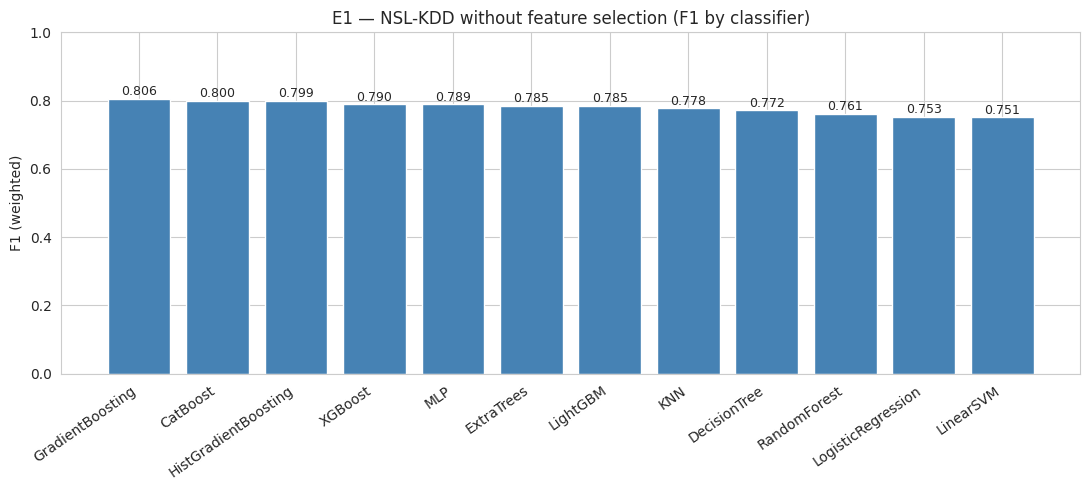

In [13]:
#  Experiment E1: No Feature Selection — NSL-KDD
print(f"[{datetime.now().strftime('%H:%M:%S')}] Starting experiment E1 ...")

e1_path = RESULTS_DIR / 'e1_results.csv'
if e1_path.exists():
    results_df = pd.read_csv(e1_path)
    print('Loaded existing E1 results.')
else:
    selector = NoSelector()
    results = run_experiment(
        nsl_X_train, nsl_X_test, nsl_y_train, nsl_y_test,
        selector=selector,
        models_dict=get_models(),
        dataset_name='nsl_kdd',
        method_name='NoSelection',
        seed=42,
        feature_names=nsl_feat
    )
    results_df = save_results(results, 'e1_results.csv')

display(results_df)

fig, ax = plt.subplots(figsize=(11, 5))
order = results_df.sort_values('f1_score', ascending=False)
ax.bar(order['classifier'], order['f1_score'], color='steelblue')
ax.set_ylabel('F1 (weighted)')
ax.set_title('E1 — NSL-KDD without feature selection (F1 by classifier)')
ax.set_ylim(0, 1.0)
plt.xticks(rotation=35, ha='right')
for i, v in enumerate(order['f1_score']):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'e1_f1_by_classifier.png')
plt.savefig(FIGURES_DIR / 'e1_f1_by_classifier.pdf')
plt.show()


# Experiment E2: Baseline Feature Selection Methods — NSL-KDD


[03:45:41] Starting experiment E2 ...
Loaded existing E2 results.


,dataset,method,classifier,seed,n_selected,n_total,reduction_ratio,accuracy,precision,recall,f1_score,f1_macro,roc_auc,fit_time,clf_time
0,nsl_kdd,MutualInfo,LogisticRegression,42,20,121,0.834711,0.715046,0.778756,0.715046,0.710077,0.713234,0.887058,85.914370,2.559099
1,nsl_kdd,MutualInfo,LinearSVM,42,20,121,0.834711,0.714913,0.778992,0.714913,0.709885,0.713070,NaN,85.914370,0.583078
2,nsl_kdd,MutualInfo,DecisionTree,42,20,121,0.834711,0.764549,0.828760,0.764549,0.761138,0.763411,0.802899,85.914370,0.456916
3,nsl_kdd,MutualInfo,RandomForest,42,20,121,0.834711,0.769784,0.835042,0.769784,0.766407,0.768650,0.936542,85.914370,5.718275
4,nsl_kdd,MutualInfo,ExtraTrees,42,20,121,0.834711,0.764549,0.828760,0.764549,0.761138,0.763411,0.916944,85.914370,4.911537
5,nsl_kdd,MutualInfo,GradientBoosting,42,20,121,0.834711,0.784289,0.841223,0.784289,0.782055,0.783664,0.939264,85.914370,18.503692
6,nsl_kdd,MutualInfo,HistGradientBoosting,42,20,121,0.834711,0.783756,0.840637,0.783756,0.781517,0.783130,0.961127,85.914370,2.868878
7,nsl_kdd,MutualInfo,XGBoost,42,20,121,0.834711,0.770582,0.834483,0.770582,0.767365,0.769526,0.961613,85.914370,0.564022
8,nsl_kdd,MutualInfo,LightGBM,42,20,121,0.834711,0.777147,0.837975,0.777147,0.774397,0.776301,0.957532,85.914370,1.737592
9,nsl_kdd,MutualInfo,CatBoost,42,20,121,0.834711,0.776881,0.837896,0.776881,0.774106,0.776024,0.958886,85.914370,0.952549


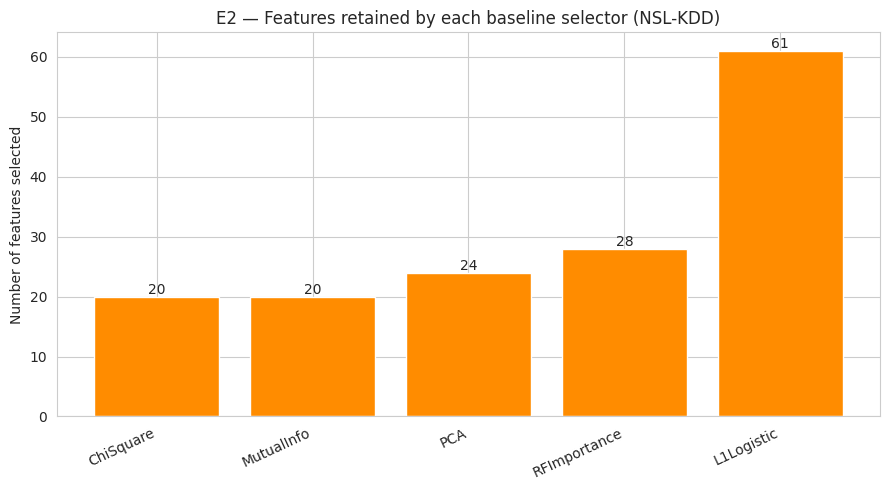

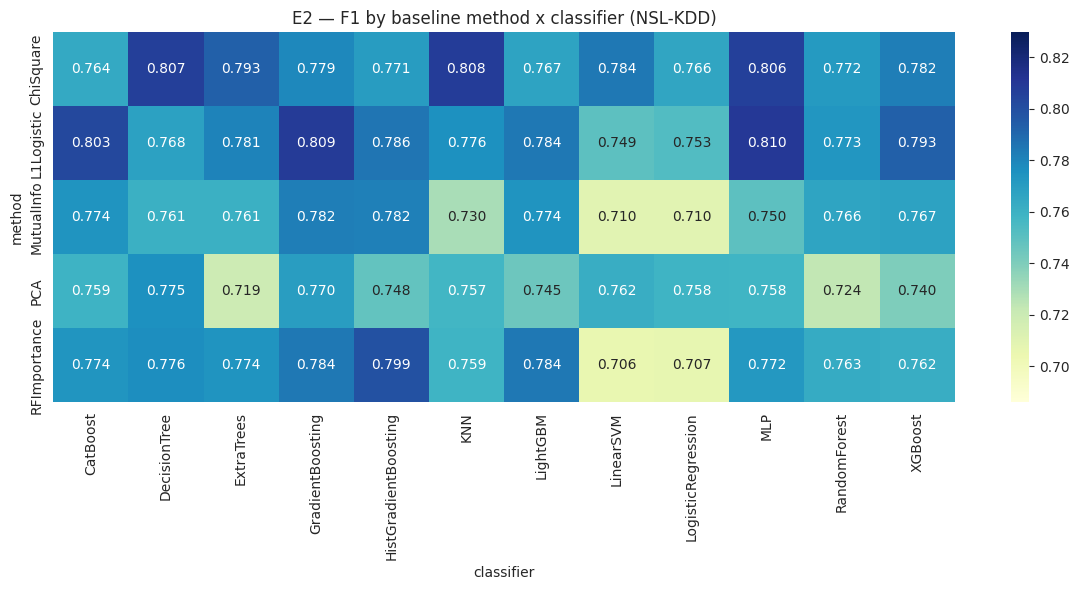

In [14]:
# Experiment E2: Baseline Feature Selection Methods — NSL-KDD
print(f"[{datetime.now().strftime('%H:%M:%S')}] Starting experiment E2 ...")

e2_path = RESULTS_DIR / 'e2_results.csv'
if e2_path.exists():
    results_df = pd.read_csv(e2_path)
    print('Loaded existing E2 results.')
else:
    all_results = []
    selectors = get_baseline_selectors(k=20)
    selectors.pop('NoSelection', None)
    for name, selector in selectors.items():
        print(f'\n--- Baseline selector: {name} ---')
        res = run_experiment(
            nsl_X_train, nsl_X_test, nsl_y_train, nsl_y_test,
            selector=selector,
            models_dict=get_models(),
            dataset_name='nsl_kdd',
            method_name=name,
            seed=42,
            feature_names=nsl_feat
        )
        all_results.extend(res)
    results_df = save_results(all_results, 'e2_results.csv')

display(results_df)

fig, ax = plt.subplots(figsize=(9, 5))
feat_counts = results_df.groupby('method')['n_selected'].first().sort_values()
ax.bar(feat_counts.index, feat_counts.values, color='darkorange')
ax.set_ylabel('Number of features selected')
ax.set_title('E2 — Features retained by each baseline selector (NSL-KDD)')
plt.xticks(rotation=25, ha='right')
for i, v in enumerate(feat_counts.values):
    ax.text(i, v + 0.5, str(int(v)), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'e2_feature_counts.png')
plt.savefig(FIGURES_DIR / 'e2_feature_counts.pdf')
plt.show()

pivot = results_df.pivot_table(index='method', columns='classifier', values='f1_score')
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax,
            vmin=max(0.0, pivot.values.min() - 0.02),
            vmax=min(1.0, pivot.values.max() + 0.02))
ax.set_title('E2 — F1 by baseline method x classifier (NSL-KDD)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'e2_f1_heatmap.png')
plt.savefig(FIGURES_DIR / 'e2_f1_heatmap.pdf')
plt.show()


# Experiment E3: GA Feature Selection — NSL-KDD (Single Seed)

GA uses a GPU-XGBoost fitness estimator when GPU is available (much faster), else a CPU RandomForest. Includes fitness caching, fitness subsampling (20K rows), and early stopping on stagnation.


[03:45:46] Starting experiment E3 ...
Loaded existing E3 results.


,dataset,method,classifier,seed,n_selected,n_total,reduction_ratio,accuracy,precision,recall,f1_score,f1_macro,roc_auc
0,nsl_kdd,GA,LogisticRegression,42,10,121,0.917355,0.749290,0.796192,0.749290,0.747438,0.748867,0.863476
1,nsl_kdd,GA,LinearSVM,42,10,121,0.917355,0.744278,0.790482,0.744278,0.742421,0.743858,NaN
2,nsl_kdd,GA,DecisionTree,42,10,121,0.917355,0.778788,0.832236,0.778788,0.776774,0.778265,0.801544
3,nsl_kdd,GA,RandomForest,42,10,121,0.917355,0.759448,0.823104,0.759448,0.755954,0.758280,0.920276
4,nsl_kdd,GA,ExtraTrees,42,10,121,0.917355,0.758384,0.826092,0.758384,0.754411,0.756974,0.886288
5,nsl_kdd,GA,GradientBoosting,42,10,121,0.917355,0.780252,0.836962,0.780252,0.777960,0.779609,0.920743
6,nsl_kdd,GA,HistGradientBoosting,42,10,121,0.917355,0.795112,0.843680,0.795112,0.793774,0.794829,0.944715
7,nsl_kdd,GA,XGBoost,42,10,121,0.917355,0.769562,0.829194,0.769562,0.766753,0.768704,0.954877
8,nsl_kdd,GA,LightGBM,42,10,121,0.917355,0.766900,0.828202,0.766900,0.763855,0.765936,0.945083
9,nsl_kdd,GA,CatBoost,42,10,121,0.917355,0.777369,0.835475,0.777369,0.774885,0.776645,0.959382


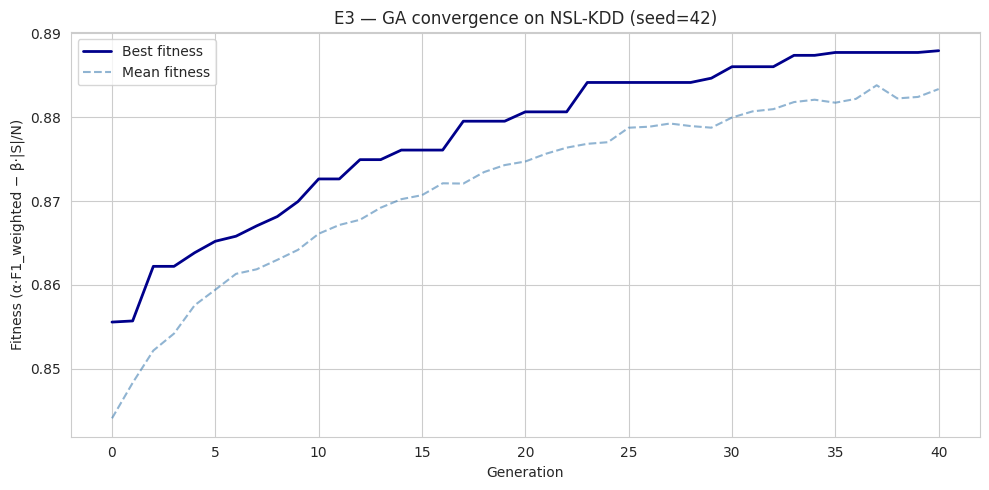

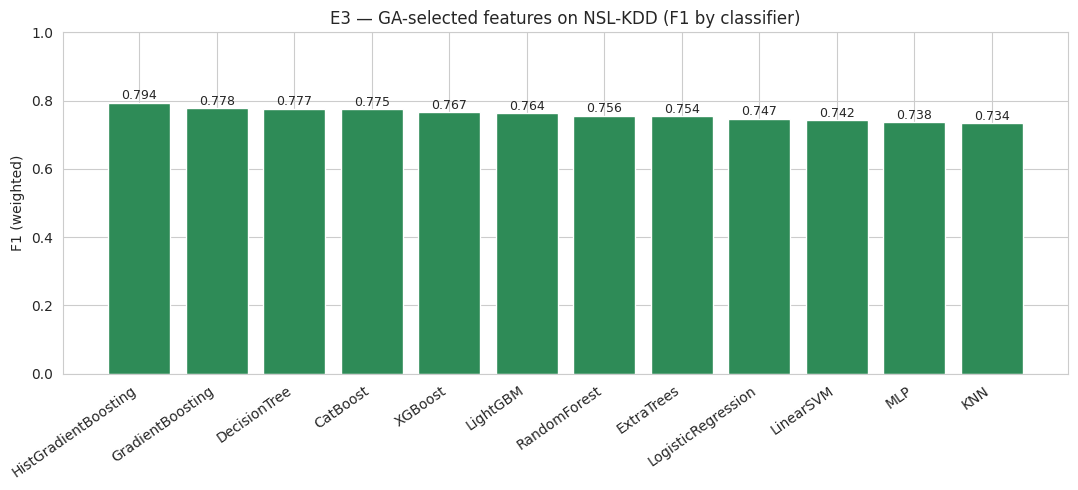

In [15]:
#  Experiment E3: GA Feature Selection — NSL-KDD (single seed)
print(f"[{datetime.now().strftime('%H:%M:%S')}] Starting experiment E3 ...")

e3_path = RESULTS_DIR / 'e3_results.csv'
e3_hist_path = CHECKPOINT_DIR / 'e3_ga_history.pkl'

if e3_path.exists() and e3_hist_path.exists():
    results_df = pd.read_csv(e3_path)
    hist = joblib.load(e3_hist_path)
    print('Loaded existing E3 results.')
else:
    ga = GeneticFeatureSelector(
        estimator=make_ga_fitness_estimator(seed=42),
        n_features=nsl_X_train.shape[1],
        pop_size=40, generations=40,
        alpha=0.9, beta=0.1,
        crossover_rate=0.8, mutation_rate=0.02,
        cv_folds=3, random_state=42,
        checkpoint_dir=CHECKPOINT_DIR,
        fitness_subsample=20000,
        patience=10
    )
    ga.fit(nsl_X_train, nsl_y_train, feature_names=nsl_feat)

    hist = {
        'best_history': ga.best_fitness_history_,
        'mean_history': ga.mean_fitness_history_,
        'selected_indices': ga.selected_indices_.tolist(),
        'selected_names':   ga.selected_feature_names_,
        'n_selected':       ga.n_selected_,
        'generations_run':  ga.generations_run_,
        'stopped_early':    ga.stopped_early_
    }
    joblib.dump(hist, e3_hist_path)

    print(f'\nGA selected {ga.n_selected_}/{nsl_X_train.shape[1]} features '
          f'(generations run: {ga.generations_run_}, early stop: {ga.stopped_early_})')

    # Evaluate all classifiers on the GA-selected subset
    X_tr_sel = ga.transform(nsl_X_train)
    X_te_sel = ga.transform(nsl_X_test)

    all_results = []
    for clf_name, clf in get_models().items():
        try:
            clf_c = clf.__class__(**clf.get_params())
        except Exception:
            clf_c = clf
        try:
            clf_c.fit(X_tr_sel, nsl_y_train)
            y_pred = clf_c.predict(X_te_sel)
            try:
                y_prob = clf_c.predict_proba(X_te_sel)
            except Exception:
                y_prob = None
        except Exception as e:
            print(f'  {clf_name:22s} FAILED: {e}')
            continue
        rec = evaluate_model(nsl_y_test, y_pred, y_prob,
                             method_name='GA',
                             classifier_name=clf_name,
                             dataset_name='nsl_kdd',
                             n_selected=ga.n_selected_,
                             n_total=nsl_X_train.shape[1],
                             seed=42)
        all_results.append(rec)
        print(f'  {clf_name:22s} F1={rec["f1_score"]:.4f} ACC={rec["accuracy"]:.4f}')

    results_df = save_results(all_results, 'e3_results.csv')

display(results_df)

# Convergence curve
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hist['best_history'], label='Best fitness', color='darkblue', linewidth=2)
ax.plot(hist['mean_history'], label='Mean fitness', color='steelblue',
        alpha=0.6, linewidth=1.5, linestyle='--')
ax.set_xlabel('Generation')
ax.set_ylabel('Fitness (α·F1_weighted − β·|S|/N)')
ax.set_title('E3 — GA convergence on NSL-KDD (seed=42)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'e3_ga_convergence.png')
plt.savefig(FIGURES_DIR / 'e3_ga_convergence.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
order = results_df.sort_values('f1_score', ascending=False)
ax.bar(order['classifier'], order['f1_score'], color='seagreen')
ax.set_ylabel('F1 (weighted)')
ax.set_title('E3 — GA-selected features on NSL-KDD (F1 by classifier)')
ax.set_ylim(0, 1.0)
plt.xticks(rotation=35, ha='right')
for i, v in enumerate(order['f1_score']):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'e3_f1_by_classifier.png')
plt.savefig(FIGURES_DIR / 'e3_f1_by_classifier.pdf')
plt.show()


# Experiment E4: No Selection and Baselines — UNSW-NB15


[03:45:51] Starting experiment E4 ...
Loaded existing E4 results.


,dataset,method,classifier,seed,n_selected,n_total,reduction_ratio,accuracy,precision,recall,f1_score,f1_macro,roc_auc,fit_time,clf_time
0,unsw_nb15,NoSelection,LogisticRegression,42,194,194,0.000000,0.734171,0.822169,0.734171,0.736302,0.733859,0.910855,0.000093,10.485599
1,unsw_nb15,NoSelection,LinearSVM,42,194,194,0.000000,0.739324,0.836720,0.739324,0.740719,0.739201,NaN,0.000093,6.537916
2,unsw_nb15,NoSelection,DecisionTree,42,194,194,0.000000,0.805067,0.848119,0.805067,0.808569,0.802302,0.932150,0.000093,2.633503
3,unsw_nb15,NoSelection,RandomForest,42,194,194,0.000000,0.823065,0.868962,0.823065,0.826203,0.820781,0.961961,0.000093,17.654358
4,unsw_nb15,NoSelection,ExtraTrees,42,194,194,0.000000,0.811295,0.860197,0.811295,0.814580,0.809125,0.952644,0.000093,15.905600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,unsw_nb15,PCA,XGBoost,42,24,194,0.876289,0.787923,0.846385,0.787923,0.791302,0.786280,0.935537,0.158624,0.748835
68,unsw_nb15,PCA,LightGBM,42,24,194,0.876289,0.771538,0.846612,0.771538,0.774346,0.770754,0.933261,0.158624,2.264126
69,unsw_nb15,PCA,CatBoost,42,24,194,0.876289,0.771760,0.845415,0.771760,0.774644,0.770915,0.931755,0.158624,1.196602
70,unsw_nb15,PCA,KNN,42,24,194,0.876289,0.783344,0.830208,0.783344,0.787154,0.780701,0.899261,0.158624,66.946341


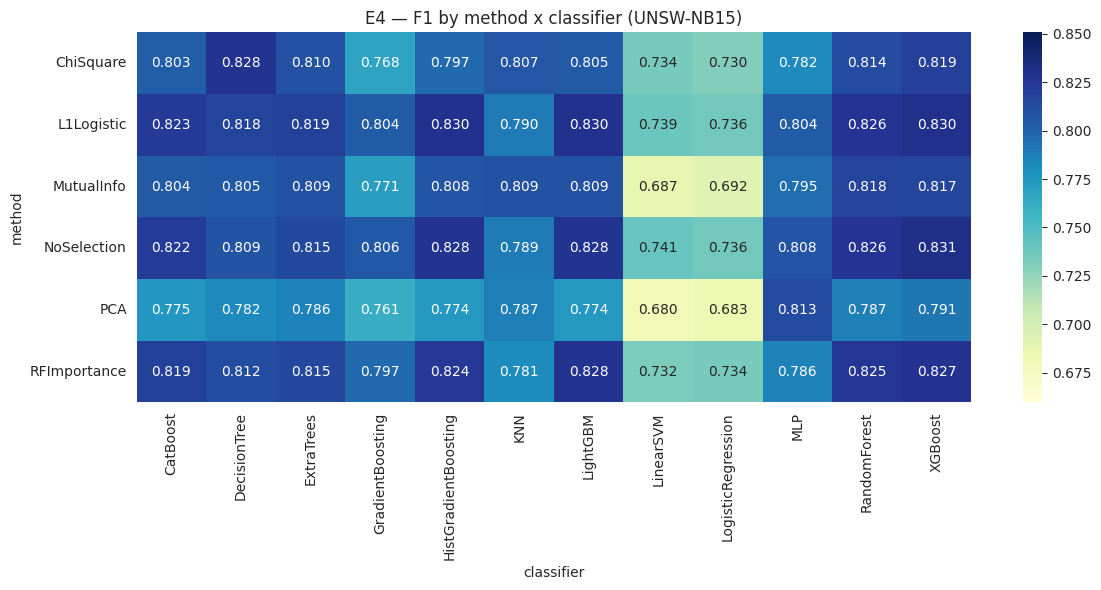

In [16]:
#  Experiment E4: No Selection and Baselines — UNSW-NB15
print(f"[{datetime.now().strftime('%H:%M:%S')}] Starting experiment E4 ...")

e4_path = RESULTS_DIR / 'e4_results.csv'
if e4_path.exists():
    results_df = pd.read_csv(e4_path)
    print('Loaded existing E4 results.')
else:
    all_results = []
    selectors = get_baseline_selectors(k=20)
    for name, selector in selectors.items():
        print(f'\n--- UNSW baseline selector: {name} ---')
        res = run_experiment(
            unsw_X_train, unsw_X_test, unsw_y_train, unsw_y_test,
            selector=selector,
            models_dict=get_models(),
            dataset_name='unsw_nb15',
            method_name=name,
            seed=42,
            feature_names=unsw_feat
        )
        all_results.extend(res)
    results_df = save_results(all_results, 'e4_results.csv')

display(results_df)

pivot = results_df.pivot_table(index='method', columns='classifier', values='f1_score')
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax,
            vmin=max(0.0, pivot.values.min() - 0.02),
            vmax=min(1.0, pivot.values.max() + 0.02))
ax.set_title('E4 — F1 by method x classifier (UNSW-NB15)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'e4_f1_heatmap.png')
plt.savefig(FIGURES_DIR / 'e4_f1_heatmap.pdf')
plt.show()


# Experiment E5: GA Feature Selection — UNSW-NB15 (Single Seed)


[03:45:56] Starting experiment E5 ...
Loaded existing E5 results.


,dataset,method,classifier,seed,n_selected,n_total,reduction_ratio,accuracy,precision,recall,f1_score,f1_macro,roc_auc
0,unsw_nb15,GA,LogisticRegression,42,35,194,0.819588,0.659475,0.750923,0.659475,0.660871,0.659385,0.739948
1,unsw_nb15,GA,LinearSVM,42,35,194,0.819588,0.654934,0.742377,0.654934,0.656797,0.654768,NaN
2,unsw_nb15,GA,DecisionTree,42,35,194,0.819588,0.811814,0.859134,0.811814,0.815123,0.809520,0.944916
3,unsw_nb15,GA,RandomForest,42,35,194,0.819588,0.820989,0.862612,0.820989,0.824224,0.818304,0.948768
4,unsw_nb15,GA,ExtraTrees,42,35,194,0.819588,0.817875,0.857771,0.817875,0.821183,0.814976,0.928101
5,unsw_nb15,GA,GradientBoosting,42,35,194,0.819588,0.790351,0.856021,0.790351,0.793411,0.789154,0.955453
6,unsw_nb15,GA,HistGradientBoosting,42,35,194,0.819588,0.824640,0.872714,0.824640,0.827713,0.822545,0.972368
7,unsw_nb15,GA,XGBoost,42,35,194,0.819588,0.827198,0.867832,0.827198,0.830331,0.824512,0.967611
8,unsw_nb15,GA,LightGBM,42,35,194,0.819588,0.822898,0.871560,0.822898,0.825990,0.820828,0.973024
9,unsw_nb15,GA,CatBoost,42,35,194,0.819588,0.815169,0.866585,0.815169,0.818332,0.813227,0.969115


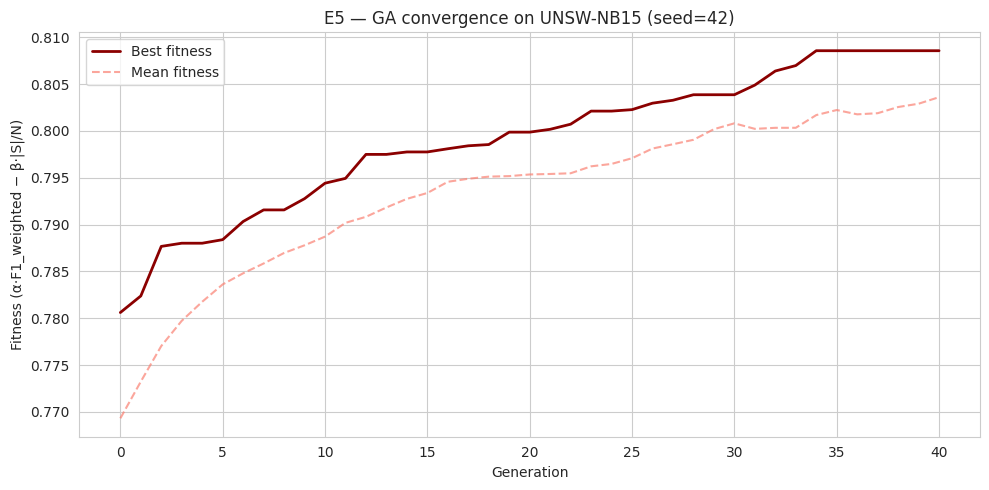

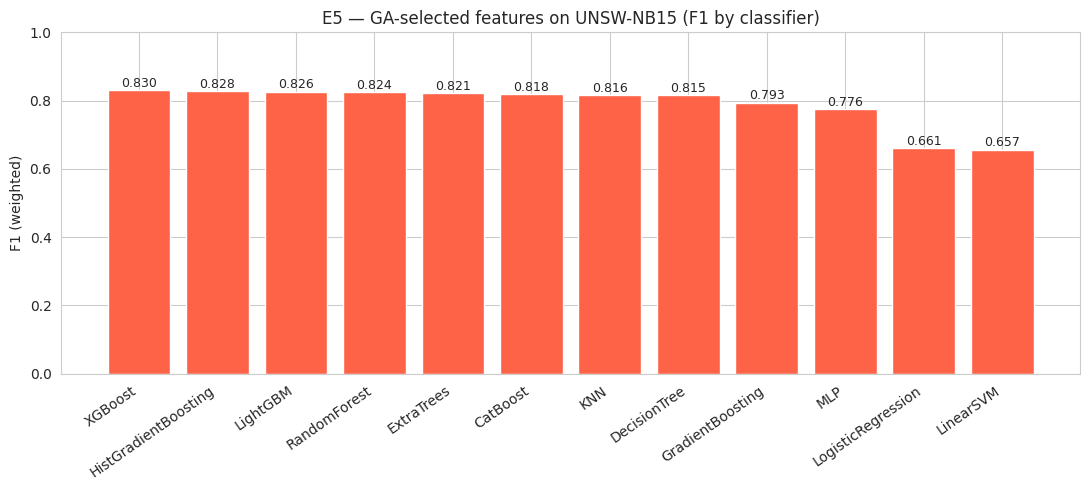

In [17]:
#  Experiment E5: GA Feature Selection — UNSW-NB15 (single seed)
print(f"[{datetime.now().strftime('%H:%M:%S')}] Starting experiment E5 ...")

e5_path = RESULTS_DIR / 'e5_results.csv'
e5_hist_path = CHECKPOINT_DIR / 'e5_ga_history.pkl'

if e5_path.exists() and e5_hist_path.exists():
    results_df = pd.read_csv(e5_path)
    hist = joblib.load(e5_hist_path)
    print('Loaded existing E5 results.')
else:
    ga = GeneticFeatureSelector(
        estimator=make_ga_fitness_estimator(seed=42),
        n_features=unsw_X_train.shape[1],
        pop_size=40, generations=40,
        alpha=0.9, beta=0.1,
        crossover_rate=0.8, mutation_rate=0.02,
        cv_folds=3, random_state=42,
        checkpoint_dir=CHECKPOINT_DIR,
        fitness_subsample=20000,
        patience=10
    )
    ga.fit(unsw_X_train, unsw_y_train, feature_names=unsw_feat)
    hist = {
        'best_history': ga.best_fitness_history_,
        'mean_history': ga.mean_fitness_history_,
        'selected_indices': ga.selected_indices_.tolist(),
        'selected_names':   ga.selected_feature_names_,
        'n_selected':       ga.n_selected_,
        'generations_run':  ga.generations_run_,
        'stopped_early':    ga.stopped_early_
    }
    joblib.dump(hist, e5_hist_path)

    X_tr_sel = ga.transform(unsw_X_train)
    X_te_sel = ga.transform(unsw_X_test)

    all_results = []
    for clf_name, clf in get_models().items():
        try:
            clf_c = clf.__class__(**clf.get_params())
        except Exception:
            clf_c = clf
        try:
            clf_c.fit(X_tr_sel, unsw_y_train)
            y_pred = clf_c.predict(X_te_sel)
            try:
                y_prob = clf_c.predict_proba(X_te_sel)
            except Exception:
                y_prob = None
        except Exception as e:
            print(f'  {clf_name:22s} FAILED: {e}')
            continue
        rec = evaluate_model(unsw_y_test, y_pred, y_prob,
                             method_name='GA',
                             classifier_name=clf_name,
                             dataset_name='unsw_nb15',
                             n_selected=ga.n_selected_,
                             n_total=unsw_X_train.shape[1],
                             seed=42)
        all_results.append(rec)
        print(f'  {clf_name:22s} F1={rec["f1_score"]:.4f} ACC={rec["accuracy"]:.4f}')

    results_df = save_results(all_results, 'e5_results.csv')

display(results_df)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hist['best_history'], label='Best fitness', color='darkred', linewidth=2)
ax.plot(hist['mean_history'], label='Mean fitness', color='salmon',
        alpha=0.7, linewidth=1.5, linestyle='--')
ax.set_xlabel('Generation')
ax.set_ylabel('Fitness (α·F1_weighted − β·|S|/N)')
ax.set_title('E5 — GA convergence on UNSW-NB15 (seed=42)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'e5_ga_convergence.png')
plt.savefig(FIGURES_DIR / 'e5_ga_convergence.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
order = results_df.sort_values('f1_score', ascending=False)
ax.bar(order['classifier'], order['f1_score'], color='tomato')
ax.set_ylabel('F1 (weighted)')
ax.set_title('E5 — GA-selected features on UNSW-NB15 (F1 by classifier)')
ax.set_ylim(0, 1.0)
plt.xticks(rotation=35, ha='right')
for i, v in enumerate(order['f1_score']):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'e5_f1_by_classifier.png')
plt.savefig(FIGURES_DIR / 'e5_f1_by_classifier.pdf')
plt.show()


# Experiment E6: GA Stability Analysis — Multiple Seeds (NSL-KDD)

Runs GA feature selection across 5 random seeds. Quantifies stability using pairwise Jaccard similarity and feature selection frequency.


[03:46:00] Starting experiment E6 ...
Loaded existing E6 results.


,dataset,method,classifier,seed,n_selected,n_total,reduction_ratio,accuracy,precision,recall,f1_score,f1_macro,roc_auc,best_fitness,generations_run,stopped_early
0,nsl_kdd,GA,LogisticRegression,42,16,121,0.867769,0.846519,0.846683,0.846519,0.846389,0.846080,0.933968,0.875976,25,False
1,nsl_kdd,GA,RandomForest,42,16,121,0.867769,0.992526,0.992527,0.992526,0.992526,0.992515,0.998872,0.875976,25,False
2,nsl_kdd,GA,LogisticRegression,123,15,121,0.876033,0.922199,0.923917,0.922199,0.922013,0.921803,0.965303,0.876683,25,False
3,nsl_kdd,GA,RandomForest,123,15,121,0.876033,0.992964,0.992965,0.992964,0.992964,0.992954,0.999355,0.876683,25,False
4,nsl_kdd,GA,LogisticRegression,256,19,121,0.842975,0.938729,0.939252,0.938729,0.938665,0.938535,0.965316,0.875477,25,False
5,nsl_kdd,GA,RandomForest,256,19,121,0.842975,0.993604,0.993604,0.993604,0.993604,0.993595,0.998942,0.875477,25,False
6,nsl_kdd,GA,LogisticRegression,789,16,121,0.867769,0.866786,0.874904,0.866786,0.865607,0.865027,0.887217,0.878557,25,False
7,nsl_kdd,GA,RandomForest,789,16,121,0.867769,0.994546,0.994550,0.994546,0.994546,0.994538,0.999487,0.878557,25,False
8,nsl_kdd,GA,LogisticRegression,1024,16,121,0.867769,0.903582,0.904121,0.903582,0.903466,0.903254,0.956599,0.876997,25,False
9,nsl_kdd,GA,RandomForest,1024,16,121,0.867769,0.992897,0.992897,0.992897,0.992897,0.992886,0.998932,0.876997,25,False


,classifier,n_seeds,mean_f1,std_f1,mean_accuracy,std_accuracy,mean_n_selected,std_n_selected,mean_pairwise_jaccard
0,LogisticRegression,5,0.895228,0.038518,0.895563,0.038310,16.4,1.356466,0.136934
1,RandomForest,5,0.993307,0.000794,0.993307,0.000794,16.4,1.356466,0.136934


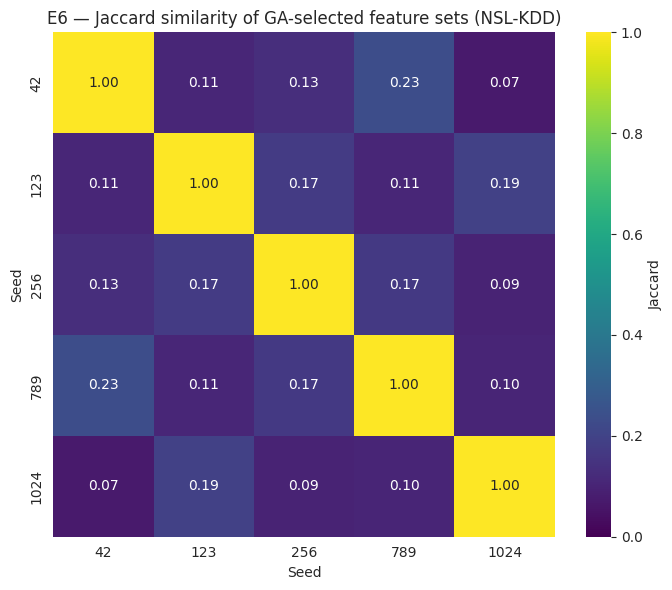

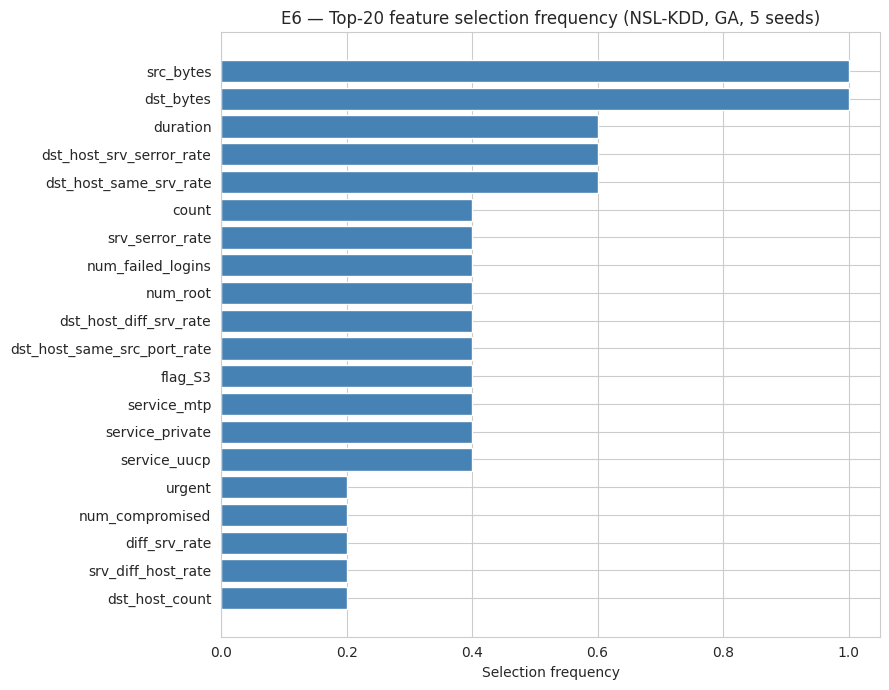

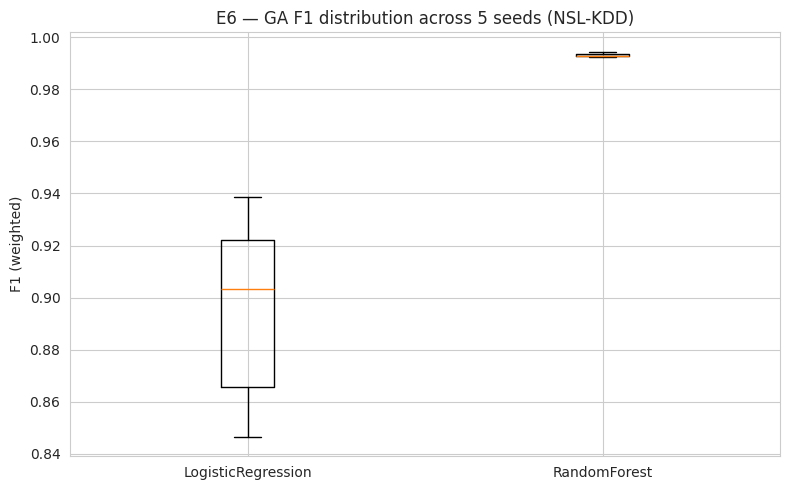

In [18]:
#  Experiment E6: GA Stability Analysis (NSL-KDD, multiple seeds)
print(f"[{datetime.now().strftime('%H:%M:%S')}] Starting experiment E6 ...")

SEEDS = [42, 123, 256, 789, 1024]
e6_detail_path   = RESULTS_DIR / 'e6_per_seed.csv'
e6_stability_path = RESULTS_DIR / 'e6_stability.csv'
e6_sets_path      = CHECKPOINT_DIR / 'e6_selected_sets.pkl'

if e6_detail_path.exists() and e6_stability_path.exists() and e6_sets_path.exists():
    per_seed_df  = pd.read_csv(e6_detail_path)
    stability_df = pd.read_csv(e6_stability_path)
    selected_sets = joblib.load(e6_sets_path)
    print('Loaded existing E6 results.')
else:
    per_seed_records = []
    selected_sets = []
    n_total = nsl_X_train.shape[1]

    for s in SEEDS:
        print(f'\n--- Seed {s} ---')
        X_all  = np.vstack([nsl_X_train, nsl_X_test])
        y_all  = np.concatenate([nsl_y_train, nsl_y_test])
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_all, y_all, test_size=0.2, stratify=y_all, random_state=s
        )

        ga = GeneticFeatureSelector(
            estimator=make_ga_fitness_estimator(seed=s),
            n_features=X_tr.shape[1],
            pop_size=30, generations=25,
            alpha=0.9, beta=0.1,
            crossover_rate=0.8, mutation_rate=0.02,
            cv_folds=3, random_state=s,
            checkpoint_dir=None, verbose=False,
            fitness_subsample=15000,
            patience=8
        )
        ga.fit(X_tr, y_tr, feature_names=nsl_feat)
        selected_sets.append(list(ga.selected_indices_))

        for clf_name, clf in fast_models().items():
            try:
                clf_c = clf.__class__(**clf.get_params())
            except Exception:
                clf_c = clf
            clf_c.fit(ga.transform(X_tr), y_tr)
            y_pred = clf_c.predict(ga.transform(X_te))
            try:
                y_prob = clf_c.predict_proba(ga.transform(X_te))
            except Exception:
                y_prob = None
            rec = evaluate_model(y_te, y_pred, y_prob,
                                 method_name='GA',
                                 classifier_name=clf_name,
                                 dataset_name='nsl_kdd',
                                 n_selected=ga.n_selected_,
                                 n_total=n_total,
                                 seed=s)
            rec['best_fitness']    = ga.best_fitness_
            rec['generations_run'] = ga.generations_run_
            rec['stopped_early']   = ga.stopped_early_
            per_seed_records.append(rec)
            print(f'  seed={s} {clf_name:22s} F1={rec["f1_score"]:.4f} n_sel={ga.n_selected_}')

    per_seed_df = pd.DataFrame(per_seed_records)
    per_seed_df.to_csv(e6_detail_path, index=False)
    joblib.dump(selected_sets, e6_sets_path)

    mean_jac = mean_pairwise_jaccard(selected_sets)
    n_sel_arr = np.array([len(s) for s in selected_sets])

    rows = []
    for clf_name in per_seed_df['classifier'].unique():
        sub = per_seed_df[per_seed_df['classifier'] == clf_name]
        rows.append({
            'classifier':            clf_name,
            'n_seeds':               len(SEEDS),
            'mean_f1':               sub['f1_score'].mean(),
            'std_f1':                sub['f1_score'].std(),
            'mean_accuracy':         sub['accuracy'].mean(),
            'std_accuracy':          sub['accuracy'].std(),
            'mean_n_selected':       n_sel_arr.mean(),
            'std_n_selected':        n_sel_arr.std(),
            'mean_pairwise_jaccard': mean_jac
        })
    stability_df = pd.DataFrame(rows)
    stability_df.to_csv(e6_stability_path, index=False)
    print(f'\nMean pairwise Jaccard (selected feature sets): {mean_jac:.4f}')

display(per_seed_df)
display(stability_df)

fig = plot_jaccard_heatmap(selected_sets, SEEDS,
                            title='E6 — Jaccard similarity of GA-selected feature sets (NSL-KDD)')
plt.savefig(FIGURES_DIR / 'e6_jaccard_heatmap.png')
plt.savefig(FIGURES_DIR / 'e6_jaccard_heatmap.pdf')
plt.show()

freq_df = feature_frequency_table(selected_sets, nsl_feat, n_features=nsl_X_train.shape[1])
freq_df.to_csv(RESULTS_DIR / 'e6_feature_frequency.csv', index=False)
fig = plot_feature_frequency(freq_df, top_n=20,
                              title='E6 — Top-20 feature selection frequency (NSL-KDD, GA, 5 seeds)')
plt.savefig(FIGURES_DIR / 'e6_feature_frequency.png')
plt.savefig(FIGURES_DIR / 'e6_feature_frequency.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
clfs = per_seed_df['classifier'].unique().tolist()
data = [per_seed_df[per_seed_df['classifier'] == c]['f1_score'].values for c in clfs]
ax.boxplot(data, labels=clfs)
ax.set_ylabel('F1 (weighted)')
ax.set_title('E6 — GA F1 distribution across 5 seeds (NSL-KDD)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'e6_boxplot_f1.png')
plt.savefig(FIGURES_DIR / 'e6_boxplot_f1.pdf')
plt.show()


# Experiment E7: Cross-Dataset Transfer — NSL-KDD to UNSW-NB15

Reuses the E3 GA selection rather than re-running the GA. Other selectors are re-fit on the full source.


[03:46:05] Starting experiment E7 ...
Loaded existing E7 results.


,source,target,selector,classifier,n_selected_source,n_transferred,n_missing,transfer_ratio,insufficient_intersection,within_f1,cross_f1,delta_M,cross_accuracy,cross_precision,cross_recall,cross_auc
0,nsl_kdd,unsw_nb15,NoSelection,RandomForestClassifier,121.0,4,117.0,0.033058,False,0.761410,0.616633,0.144777,0.647094,0.623600,0.647094,0.574703
1,nsl_kdd,unsw_nb15,NoSelection,LogisticRegression,121.0,4,117.0,0.033058,False,0.753010,0.616633,0.136377,0.647094,0.623600,0.647094,0.574703
2,nsl_kdd,unsw_nb15,MutualInfo,RandomForestClassifier,20.0,1,19.0,0.050000,True,0.766407,0.591527,0.174881,0.641830,0.612217,0.641830,0.550709
3,nsl_kdd,unsw_nb15,MutualInfo,LogisticRegression,20.0,1,19.0,0.050000,True,0.710077,0.591527,0.118551,0.641830,0.612217,0.641830,0.550709
4,nsl_kdd,unsw_nb15,ChiSquare,RandomForestClassifier,20.0,2,18.0,0.100000,True,0.771781,0.613650,0.158131,0.651079,0.627530,0.651079,0.568904
5,nsl_kdd,unsw_nb15,ChiSquare,LogisticRegression,20.0,2,18.0,0.100000,True,0.765683,0.613650,0.152033,0.651079,0.627530,0.651079,0.568904
6,nsl_kdd,unsw_nb15,L1Logistic,RandomForestClassifier,61.0,2,59.0,0.032787,True,0.773251,0.613650,0.159600,0.651079,0.627530,0.651079,0.568904
7,nsl_kdd,unsw_nb15,L1Logistic,LogisticRegression,61.0,2,59.0,0.032787,True,0.752963,0.613650,0.139313,0.651079,0.627530,0.651079,0.568904
8,nsl_kdd,unsw_nb15,RFImportance,RandomForestClassifier,28.0,1,27.0,0.035714,True,0.763403,0.591527,0.171876,0.641830,0.612217,0.641830,0.550709
9,nsl_kdd,unsw_nb15,RFImportance,LogisticRegression,28.0,1,27.0,0.035714,True,0.707109,0.591527,0.115582,0.641830,0.612217,0.641830,0.550709


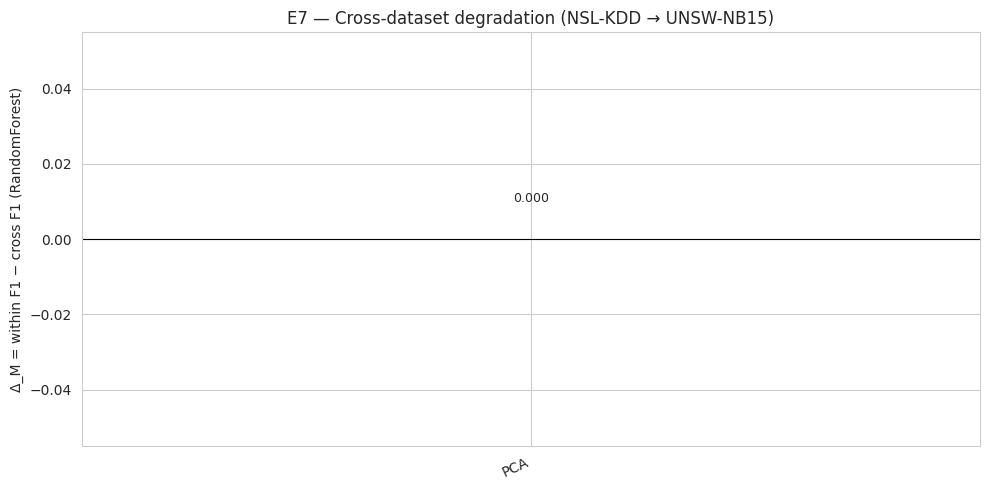

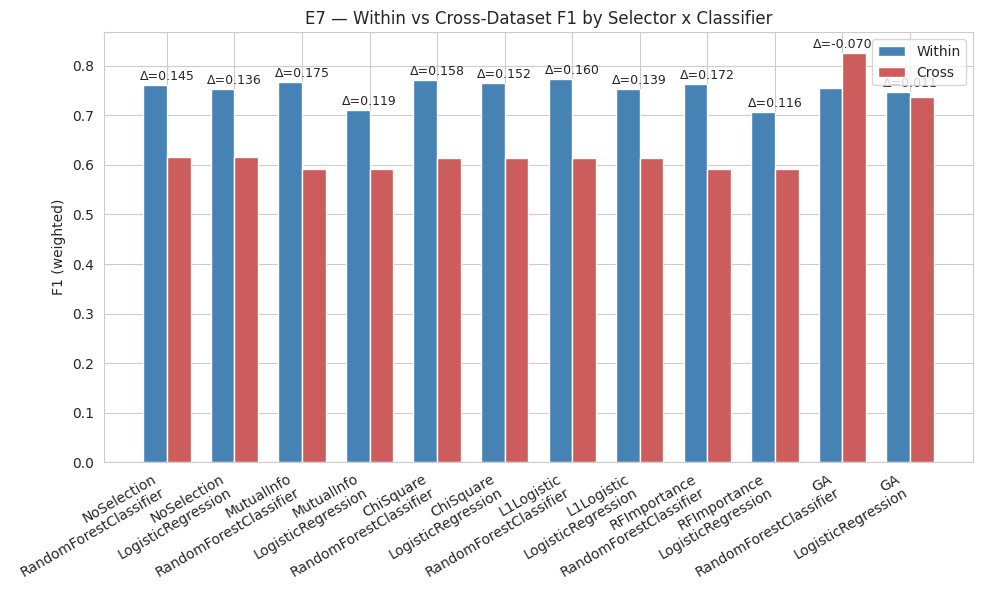

In [19]:
#  Experiment E7: Cross-Dataset Transfer (NSL -> UNSW)
print(f"[{datetime.now().strftime('%H:%M:%S')}] Starting experiment E7 ...")

e7_path = RESULTS_DIR / 'e7_transfer.csv'

if e7_path.exists():
    transfer_df = pd.read_csv(e7_path)
    print('Loaded existing E7 results.')
else:
    records = []

    selectors_to_try = get_baseline_selectors(k=20)

    # Reuse E3 GA selection if available (avoids re-running the GA)
    e3_hist_path = CHECKPOINT_DIR / 'e3_ga_history.pkl'
    if e3_hist_path.exists():
        e3_hist = joblib.load(e3_hist_path)
        selectors_to_try['GA'] = PrecomputedSelector(
            indices=e3_hist['selected_indices'],
            names=e3_hist['selected_names'],
            n_total=nsl_X_train.shape[1]
        )
        print('  Reusing E3 GA selection for transfer.')
    else:
        selectors_to_try['GA'] = GeneticFeatureSelector(
            estimator=make_ga_fitness_estimator(seed=42),
            n_features=nsl_X_train.shape[1],
            pop_size=30, generations=20,
            alpha=0.9, beta=0.1,
            crossover_rate=0.8, mutation_rate=0.02,
            cv_folds=3, random_state=42,
            checkpoint_dir=None, verbose=False,
            fitness_subsample=15000, patience=8
        )

    # Within-dataset F1 lookup
    within_df_parts = []
    for fname in ['e1_results.csv', 'e2_results.csv', 'e3_results.csv']:
        fpath = RESULTS_DIR / fname
        if fpath.exists():
            within_df_parts.append(pd.read_csv(fpath))
    within_df = pd.concat(within_df_parts, ignore_index=True) if within_df_parts else pd.DataFrame()

    def within_f1(method, classifier):
        if within_df.empty:
            return np.nan
        sub = within_df[(within_df['method'] == method) &
                        (within_df['classifier'] == classifier) &
                        (within_df['dataset'] == 'nsl_kdd')]
        if len(sub) == 0:
            return np.nan
        return float(sub['f1_score'].iloc[0])

    transfer_classifiers = {
        'RandomForest':       RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                                     random_state=42, n_jobs=-1),
        'LogisticRegression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1)
    }

    for sname, selector in selectors_to_try.items():
        if sname == 'PCA':
            print(f'\n--- Skipping transfer for {sname} (feature-name transfer not applicable) ---')
            for clf_name, clf in transfer_classifiers.items():
                w = within_f1(sname, clf_name)
                records.append({
                    'source': 'nsl_kdd', 'target': 'unsw_nb15',
                    'selector': sname, 'classifier': clf_name,
                    'n_selected_source': np.nan,
                    'n_transferred': 0, 'n_missing': np.nan, 'transfer_ratio': 0.0,
                    'insufficient_intersection': True,
                    'within_f1': w, 'cross_f1': np.nan, 'delta_M': np.nan,
                    'cross_accuracy': np.nan, 'cross_precision': np.nan,
                    'cross_recall': np.nan, 'cross_auc': np.nan
                })
            continue

        print(f'\n--- Transfer selector: {sname} ---')
        for clf_name, clf in transfer_classifiers.items():
            w = within_f1(sname, clf_name)
            report = cross_dataset_transfer(
                selector=selector,
                X_source_train=nsl_X_train, y_source_train=nsl_y_train,
                X_target_train=unsw_X_train, X_target_test=unsw_X_test,
                y_target_train=unsw_y_train, y_target_test=unsw_y_test,
                source_feature_names=nsl_feat, target_feature_names=unsw_feat,
                classifier=clf,
                source_name='nsl_kdd', target_name='unsw_nb15',
                within_score=w
            )
            print(f'  {sname} / {clf_name}: within={w} cross={report["cross_f1"]:.4f} '
                  f'delta_M={report["delta_M"]} transferred={report["n_transferred"]}/{report["n_selected_source"]}')
            records.append(report)

    transfer_df = pd.DataFrame(records)
    transfer_df.to_csv(e7_path, index=False)
    print(f'Saved {len(transfer_df)} transfer records to {e7_path}')

display(transfer_df)

sub = transfer_df[transfer_df['classifier'] == 'RandomForest'].copy()
sub = sub.sort_values('selector')
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(sub['selector'], sub['delta_M'].fillna(0).values,
       color=['gray' if pd.isna(x) else ('indianred' if x > 0 else 'steelblue') for x in sub['delta_M']])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Δ_M = within F1 − cross F1 (RandomForest)')
ax.set_title('E7 — Cross-dataset degradation (NSL-KDD → UNSW-NB15)')
plt.xticks(rotation=25, ha='right')
for i, v in enumerate(sub['delta_M'].fillna(0).values):
    ax.text(i, v + (0.01 if v >= 0 else -0.03), f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'e7_delta_m_bar.png')
plt.savefig(FIGURES_DIR / 'e7_delta_m_bar.pdf')
plt.show()

fig = plot_transfer_comparison(transfer_df.dropna(subset=['within_f1', 'cross_f1']).reset_index(drop=True),
                                metric='f1_score',
                                title='E7 — Within vs Cross-Dataset F1 by Selector x Classifier')
plt.savefig(FIGURES_DIR / 'e7_within_vs_cross.png')
plt.savefig(FIGURES_DIR / 'e7_within_vs_cross.pdf')
plt.show()


# Statistical Validation

Paired tests comparing GA vs each baseline using the 5-seed F1 scores from E6. Holm-corrected p-values.


[03:46:09] Running statistical validation ...
Loaded existing statistical results.


,comparison,ga_mean_f1,baseline_mean_f1,ga_std_f1,baseline_std_f1,t_stat,p_value_raw_ttest,w_stat,p_value_raw_wilcoxon,direction,p_value_corrected,significant
0,GA vs NoSelection,0.993307,0.995812,0.00071,0.000179,-8.062451,0.001285,0.0,0.0625,GA <= baseline,0.006290,True
1,GA vs MutualInfo,0.993307,0.994270,0.00071,0.000308,-3.096977,0.036327,0.0,0.0625,GA <= baseline,0.036327,True
2,GA vs ChiSquare,0.993307,0.982265,0.00071,0.000655,19.212112,0.000043,0.0,0.0625,GA > baseline,0.000260,True
3,GA vs L1Logistic,0.993307,0.995603,0.00071,0.000399,-8.108189,0.001258,0.0,0.0625,GA <= baseline,0.006290,True
4,GA vs RFImportance,0.993307,0.995388,0.00071,0.000295,-7.168203,0.002005,0.0,0.0625,GA <= baseline,0.006290,True
5,GA vs PCA,0.993307,0.991293,0.00071,0.000299,5.763663,0.004496,0.0,0.0625,GA > baseline,0.008993,True


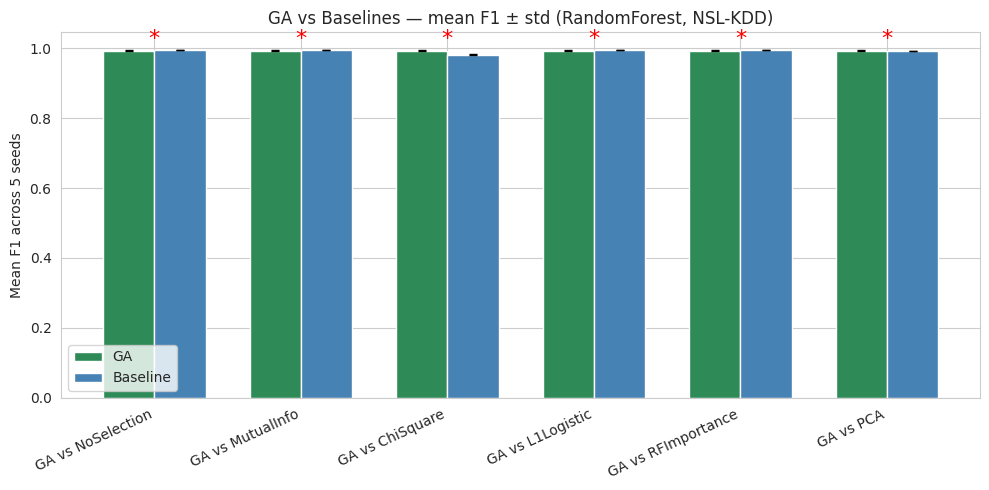

In [20]:
#  Statistical Validation
print(f"[{datetime.now().strftime('%H:%M:%S')}] Running statistical validation ...")

SEEDS = [42, 123, 256, 789, 1024]
stats_path = RESULTS_DIR / 'stats_results.csv'

if stats_path.exists():
    stats_df = pd.read_csv(stats_path)
    print('Loaded existing statistical results.')
else:
    per_seed_df = pd.read_csv(RESULTS_DIR / 'e6_per_seed.csv')
    ga_scores_rf = per_seed_df[per_seed_df['classifier'] == 'RandomForest']                    .sort_values('seed')['f1_score'].values

    baseline_seed_scores = {}
    X_all  = np.vstack([nsl_X_train, nsl_X_test])
    y_all  = np.concatenate([nsl_y_train, nsl_y_test])
    baseline_selectors_dict = get_baseline_selectors(k=20)

    for bname in baseline_selectors_dict:
        baseline_seed_scores[bname] = []

    for s in SEEDS:
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_all, y_all, test_size=0.2, stratify=y_all, random_state=s
        )
        for bname, bsel_proto in baseline_selectors_dict.items():
            try:
                bsel = bsel_proto.__class__(**{k: v for k, v in bsel_proto.__dict__.items()
                                                if not k.endswith('_') and not k.startswith('_')})
            except Exception:
                bsel = bsel_proto
            bsel.fit(X_tr, y_tr, feature_names=nsl_feat)
            X_tr_s = bsel.transform(X_tr)
            X_te_s = bsel.transform(X_te)
            clf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                          random_state=s, n_jobs=-1)
            clf.fit(X_tr_s, y_tr)
            yp = clf.predict(X_te_s)
            f1 = f1_score(y_te, yp, average='weighted', zero_division=0)
            baseline_seed_scores[bname].append(f1)
        print(f'  seed={s} baselines done.')

    rows = []
    raw_p = []
    for bname, bscores in baseline_seed_scores.items():
        bscores = np.asarray(bscores, dtype=float)
        if len(bscores) != len(ga_scores_rf):
            continue
        try:
            t_stat, p_t = stats.ttest_rel(ga_scores_rf, bscores)
        except Exception:
            t_stat, p_t = (np.nan, np.nan)
        try:
            if np.allclose(ga_scores_rf, bscores):
                w_stat, p_w = (np.nan, 1.0)
            else:
                w_stat, p_w = stats.wilcoxon(ga_scores_rf, bscores, zero_method='wilcox')
        except Exception:
            w_stat, p_w = (np.nan, np.nan)

        direction = 'GA > baseline' if np.mean(ga_scores_rf) > np.mean(bscores) else 'GA <= baseline'
        rows.append({
            'comparison':           f'GA vs {bname}',
            'ga_mean_f1':           float(np.mean(ga_scores_rf)),
            'baseline_mean_f1':     float(np.mean(bscores)),
            'ga_std_f1':            float(np.std(ga_scores_rf)),
            'baseline_std_f1':      float(np.std(bscores)),
            't_stat':               float(t_stat) if t_stat == t_stat else np.nan,
            'p_value_raw_ttest':    float(p_t)    if p_t    == p_t    else np.nan,
            'w_stat':               float(w_stat) if w_stat == w_stat else np.nan,
            'p_value_raw_wilcoxon': float(p_w)    if p_w    == p_w    else np.nan,
            'direction':            direction
        })
        raw_p.append(p_t if (p_t == p_t) else 1.0)

    if len(raw_p) > 0:
        reject, p_corr, _, _ = multipletests(raw_p, alpha=0.05, method='holm')
        for i, row in enumerate(rows):
            row['p_value_corrected'] = float(p_corr[i])
            row['significant']       = bool(reject[i])

    stats_df = pd.DataFrame(rows)
    stats_df.to_csv(stats_path, index=False)
    print(f'Saved {len(stats_df)} statistical comparisons to {stats_path}')

display(stats_df)

if len(stats_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(stats_df))
    w = 0.35
    ax.bar(x - w/2, stats_df['ga_mean_f1'],       width=w, yerr=stats_df['ga_std_f1'],
           label='GA',       color='seagreen', capsize=3)
    ax.bar(x + w/2, stats_df['baseline_mean_f1'], width=w, yerr=stats_df['baseline_std_f1'],
           label='Baseline', color='steelblue', capsize=3)
    ax.set_xticks(x)
    ax.set_xticklabels(stats_df['comparison'], rotation=25, ha='right')
    ax.set_ylabel('Mean F1 across 5 seeds')
    ax.set_title('GA vs Baselines — mean F1 ± std (RandomForest, NSL-KDD)')
    ax.legend()
    for i, sig in enumerate(stats_df.get('significant', pd.Series([False]*len(stats_df)))):
        if sig:
            ax.text(i, max(stats_df['ga_mean_f1'].iloc[i], stats_df['baseline_mean_f1'].iloc[i]) + 0.015,
                    '*', ha='center', fontsize=16, color='red')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'stats_ga_vs_baselines.png')
    plt.savefig(FIGURES_DIR / 'stats_ga_vs_baselines.pdf')
    plt.show()


# Final Results Summary


[03:46:10] Building final summary ...


,dataset,method,classifier,seed,n_selected,n_total,reduction_ratio,accuracy,precision,recall,f1_score,f1_macro,roc_auc,fit_time,clf_time
0,nsl_kdd,NoSelection,LogisticRegression,42,121,121,0.000000,0.754879,0.802781,0.754879,0.753010,0.754443,0.791218,0.000066,7.013786
1,nsl_kdd,NoSelection,LinearSVM,42,121,121,0.000000,0.753061,0.801412,0.753061,0.751111,0.752596,NaN,0.000066,3.987912
2,nsl_kdd,NoSelection,DecisionTree,42,121,121,0.000000,0.774663,0.830961,0.774663,0.772297,0.773997,0.738649,0.000066,1.444694
3,nsl_kdd,NoSelection,RandomForest,42,121,121,0.000000,0.765082,0.831890,0.765082,0.761410,0.763810,0.957386,0.000066,16.477479
4,nsl_kdd,NoSelection,ExtraTrees,42,121,121,0.000000,0.787482,0.842506,0.787482,0.785479,0.786952,0.952693,0.000066,25.138427
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,unsw_nb15,GA,XGBoost,42,35,194,0.819588,0.827198,0.867832,0.827198,0.830331,0.824512,0.967611,NaN,NaN
164,unsw_nb15,GA,LightGBM,42,35,194,0.819588,0.822898,0.871560,0.822898,0.825990,0.820828,0.973024,NaN,NaN
165,unsw_nb15,GA,CatBoost,42,35,194,0.819588,0.815169,0.866585,0.815169,0.818332,0.813227,0.969115,NaN,NaN
166,unsw_nb15,GA,KNN,42,35,194,0.819588,0.812630,0.851760,0.812630,0.816040,0.809568,0.909716,NaN,NaN


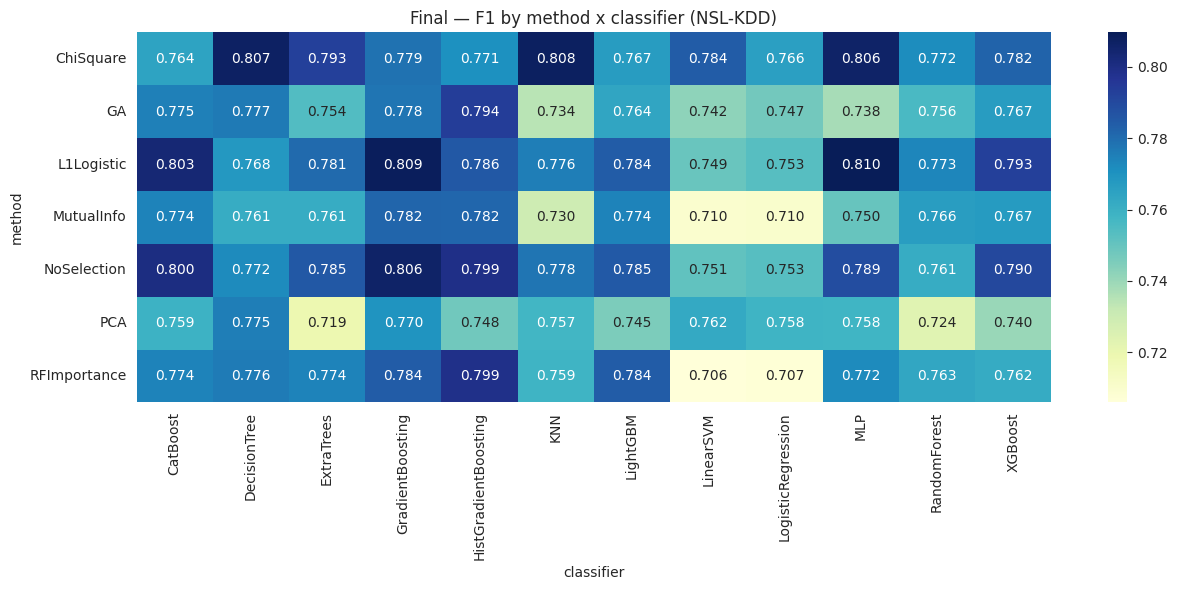

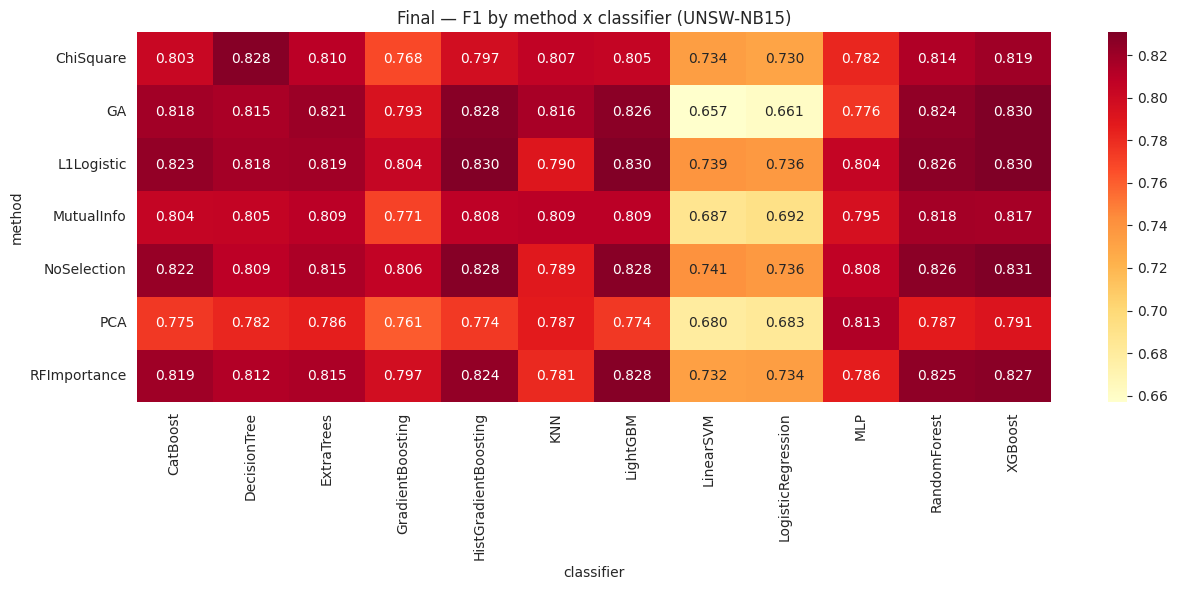

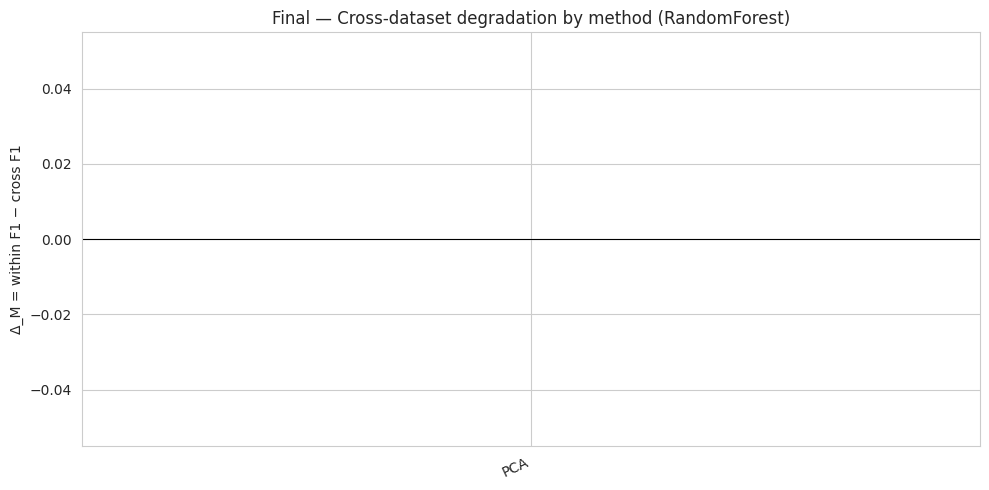

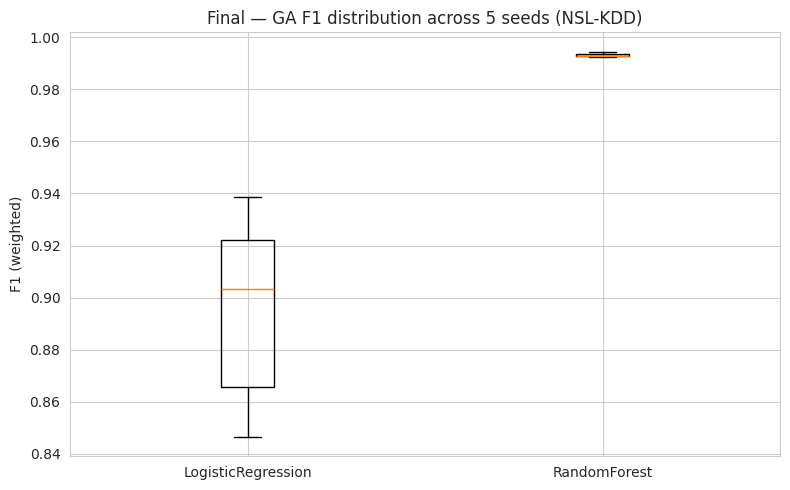


===== Top methods by mean F1 per dataset =====

[nsl_kdd]
method
ChiSquare       0.783236
L1Logistic      0.782050
NoSelection     0.780922
RFImportance    0.763447
GA              0.760526
MutualInfo      0.755632
PCA             0.751372

[unsw_nb15]
method
L1Logistic      0.804127
NoSelection     0.803124
RFImportance    0.798416
ChiSquare       0.791337
GA              0.788806
MutualInfo      0.785351
PCA             0.766166

All figures saved to: /content/drive/MyDrive/IDAI-720/ga_figures
All results saved to: /content/drive/MyDrive/IDAI-720/ga_results

[03:46:16] Notebook complete.


In [21]:
#  Final Results Summary
print(f"[{datetime.now().strftime('%H:%M:%S')}] Building final summary ...")

parts = []
for fname in ['e1_results.csv', 'e2_results.csv', 'e3_results.csv',
              'e4_results.csv', 'e5_results.csv']:
    fpath = RESULTS_DIR / fname
    if fpath.exists():
        parts.append(pd.read_csv(fpath))
final_df = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()

if not final_df.empty:
    final_df.to_csv(RESULTS_DIR / 'final_combined_results.csv', index=False)

display(final_df)

nsl_only = final_df[final_df['dataset'] == 'nsl_kdd']
if not nsl_only.empty:
    piv = nsl_only.pivot_table(index='method', columns='classifier', values='f1_score', aggfunc='mean')
    fig, ax = plt.subplots(figsize=(13, 6))
    sns.heatmap(piv, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax)
    ax.set_title('Final — F1 by method x classifier (NSL-KDD)')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'final_heatmap_nsl.png')
    plt.savefig(FIGURES_DIR / 'final_heatmap_nsl.pdf')
    plt.show()

unsw_only = final_df[final_df['dataset'] == 'unsw_nb15']
if not unsw_only.empty:
    piv = unsw_only.pivot_table(index='method', columns='classifier', values='f1_score', aggfunc='mean')
    fig, ax = plt.subplots(figsize=(13, 6))
    sns.heatmap(piv, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax)
    ax.set_title('Final — F1 by method x classifier (UNSW-NB15)')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'final_heatmap_unsw.png')
    plt.savefig(FIGURES_DIR / 'final_heatmap_unsw.pdf')
    plt.show()

if (RESULTS_DIR / 'e7_transfer.csv').exists():
    tdf = pd.read_csv(RESULTS_DIR / 'e7_transfer.csv')
    sub = tdf[tdf['classifier'] == 'RandomForest'].sort_values('selector')
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(sub['selector'], sub['delta_M'].fillna(0).values,
           color=['gray' if pd.isna(x) else ('indianred' if x > 0 else 'steelblue')
                  for x in sub['delta_M']])
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel('Δ_M = within F1 − cross F1')
    ax.set_title('Final — Cross-dataset degradation by method (RandomForest)')
    plt.xticks(rotation=25, ha='right')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'final_delta_m.png')
    plt.savefig(FIGURES_DIR / 'final_delta_m.pdf')
    plt.show()

if (RESULTS_DIR / 'e6_per_seed.csv').exists():
    psd = pd.read_csv(RESULTS_DIR / 'e6_per_seed.csv')
    clfs = psd['classifier'].unique().tolist()
    data = [psd[psd['classifier'] == c]['f1_score'].values for c in clfs]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.boxplot(data, labels=clfs)
    ax.set_ylabel('F1 (weighted)')
    ax.set_title('Final — GA F1 distribution across 5 seeds (NSL-KDD)')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'final_boxplot_ga.png')
    plt.savefig(FIGURES_DIR / 'final_boxplot_ga.pdf')
    plt.show()

if not final_df.empty:
    print('\n===== Top methods by mean F1 per dataset =====')
    for ds in final_df['dataset'].unique():
        sub = final_df[final_df['dataset'] == ds]
        ranking = sub.groupby('method')['f1_score'].mean().sort_values(ascending=False)
        print(f'\n[{ds}]')
        print(ranking.to_string())

print(f'\nAll figures saved to: {FIGURES_DIR}')
print(f'All results saved to: {RESULTS_DIR}')
print(f'\n[{datetime.now().strftime("%H:%M:%S")}] Notebook complete.')
